# RAVE-Knee: Retrieval-Augmented Visual Embedding for Knee Cartilage Segmentation
## NIfTI + CSV Edition — Journal-Grade Pipeline

**Dataset**: OAI-ZIB (507 subjects — 404 train/val + 103 test)  
**Format**: NIfTI (.nii.gz) via nnU-Net directory structure  
**Architecture**: SwinUNETR + FAISS HNSW retrieval + ICL fusion  
**Atlas**: CLAIR-Knee 103R (64×128×128, 6-class + intensity)

### Directory Structure
```
/kaggle/input/datasets/ishtiaqueahmed354/oai-zib-cm/OAIZIB-CM/OAIZIB-CM/
    imagesTr/   oaizib_001_0000.nii.gz ... oaizib_404_0000.nii.gz  (404)
    labelsTr/   oaizib_001.nii.gz      ... oaizib_404.nii.gz
    imagesTs/   oaizib_405_0000.nii.gz ... oaizib_507_0000.nii.gz  (103)
    labelsTs/   oaizib_405.nii.gz      ... oaizib_507.nii.gz
    CLAIR-Knee-103R_atlas_64x128x128.nii
    CLAIR-Knee-103R_segmentation_64x128x128.nii
```

### CSV Files (uploaded as Kaggle dataset)
| File | Rows | Key columns |
|------|------|-------------|
| `train.csv` | 404 | `image`, `mask` |
| `test.csv` | 103 | `image`, `mask` |
| `subInfo_train.csv` | 404 | `CMT-ID`, `KLGrade`, `Age`, `BMI`, `Gender`, `KneeSide` |
| `subInfo_test.csv` | 103 | `CMT-ID`, `KLGrade`, `Age`, `BMI`, `Gender`, `KneeSide` |

**CMT-ID mapping**: `oaizib_211_0000.nii.gz` → CMT-ID = **211** → subInfo row where CMT-ID=211  
**KL Grade distribution (train)**: KL-0:82 | KL-1:46 | KL-2:86 | KL-3:111 | KL-4:58 (21 NaN for IDs 384–404)


## Cell 1 — Installation

In [1]:
# # ── Install / upgrade dependencies ──────────────────────────────────────────
# import subprocess, sys

# pkgs = [
#     "monai[all]==1.3.0",
#     "torchio==0.19.6",
#     "pytorch-lightning==2.2.4",
#     "faiss-gpu",
#     "nibabel>=5.2",
#     "connected-components-3d",
#     "scikit-learn",
#     "scipy",
#     "psutil",
# ]

# for pkg in pkgs:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# print("✅ Dependencies installed")


## Cell 2 — Imports & Device Setup

In [2]:
import gc, json, os, re, sys, time, warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import nibabel as nib
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

import monai
from monai.data    import decollate_batch
from monai.inferers import SlidingWindowInferer
from monai.losses   import DiceCELoss
from monai.metrics  import DiceMetric
from monai.networks.nets import SwinUNETR
from monai.transforms import (
    AsDiscrete, Compose, EnsureType,
    LoadImaged, EnsureChannelFirstd,
    ScaleIntensityRangePercentilesd,
    RandCropByPosNegLabeld,
    RandFlipd, RandGaussianNoised, RandBiasFieldd,
    ToTensord, Orientationd, Spacingd,
)

import torchio as tio
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
import faiss

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy import ndimage, stats

from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                              cohen_kappa_score, accuracy_score, f1_score)

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "axes.grid": True,
                             "grid.alpha": 0.3, "font.size": 10})

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RAM_GB  = psutil.virtual_memory().total / 1024**3
N_CPUS  = os.cpu_count() or 4

print(f"PyTorch  : {torch.__version__}")
print(f"MONAI    : {monai.__version__}")
print(f"TorchIO  : {tio.__version__}")
print(f"Device   : {device}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"RAM      : {RAM_GB:.1f} GB")
print(f"CPU cores: {N_CPUS}")


c:\ProgramData\anaconda3\envs\Medsam_knee\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(



PyTorch  : 2.12.0.dev20260408+cu128
MONAI    : 1.5.2
TorchIO  : 0.19.6
Device   : cuda
GPU      : NVIDIA GeForce RTX 5090
VRAM     : 34.2 GB
RAM      : 31.0 GB
CPU cores: 16


In [3]:
# ── After torch imports ───────────────────────────────────────────────────────
import torch
torch.set_float32_matmul_precision('high')   # ← add this line

# 'high'   → best balance: TF32 on matmuls + convolutions, ~3× faster on RTX 5090
# 'medium' → slightly more aggressive, marginal extra speed, tiny extra precision loss
# 'highest'→ full float32 (default, slowest, ignores Tensor Cores completely)

## Cell 3 — Configuration (NIfTI + CSV Paths)

In [4]:
from dataclasses import dataclass, field

@dataclass
class Config:
    # ── Root dataset directory (nnU-Net layout) ───────────────────────────────
    base_dir:       str = "D:/ishtiaque/Knee segementation/OAI-ZIB/OAIZIB-CM/OAIZIB-CM"

    # ── CSV split files (upload as a separate Kaggle dataset) ─────────────────
    train_csv_path: str = "D:/ishtiaque/Knee segementation/OAI-ZIB/train.csv"
    test_csv_path:  str = "D:/ishtiaque/Knee segementation/OAI-ZIB/test.csv"

    # ── Subject metadata CSVs (KL grade, demographics) ───────────────────────
    sub_info_train_csv: str = "D:/ishtiaque/Knee segementation/OAI-ZIB/OAIZIB-CM/OAIZIB-CM/info/subInfo_train.csv"
    sub_info_test_csv:  str = "D:/ishtiaque/Knee segementation/OAI-ZIB/OAIZIB-CM/OAIZIB-CM/info/subInfo_test.csv"

    # ── Atlas files ───────────────────────────────────────────────────────────
    atlas_img_path: str = "OAI-ZIB/OAIZIB-CM/OAIZIB-CM/template_atlas/CLAIR-Knee-103R_atlas_64x128x128.nii"   # auto-set in __post_init__
    atlas_seg_path: str = "OAI-ZIB/OAIZIB-CM/OAIZIB-CM/template_atlas/CLAIR-Knee-103R_segmentation_64x128x128.nii"   # auto-set in __post_init__

    # ── Output / cache ────────────────────────────────────────────────────────
    output_dir:      str = "D:/ishtiaque/Knee segementation/rave_output"
    patch_cache_dir: str = "D:/ishtiaque/Knee segementation/patch_cache"

    # ── Split ratio ───────────────────────────────────────────────────────────
    val_fraction: float = 0.20   # 20% of train.csv → validation

    # ── Classes (OAI-ZIB 5-class) ────────────────────────────────────────────
    num_classes:  int = 6
    class_names:  List[str] = field(default_factory=lambda: [
        "Background","Femur", "Femoral Cartilage",
        "Tibia", "Medial Tibial Cartilage",
        "Lateral Tibial Cartilage",
    ])
    class_colors: List[Tuple] = field(default_factory=lambda: [
        (0.0, 0.0, 0.0), (0.612, 0.324, 0.923),
        (0.1, 0.9, 0.1), (0.9, 0.1, 0.1), (0.1, 0.1, 0.9),
    ])

    # ── SwinUNETR ─────────────────────────────────────────────────────────────
    img_size:       Tuple = (128, 128, 128)
    feature_size:   int   = 48
    swin_depths:    Tuple = (2, 2, 2, 2)
    swin_num_heads: Tuple = (3, 6, 12, 24)
    use_checkpoint: bool  = True
    use_v2:         bool  = False
    spatial_dims:   int   = 3
    drop_rate:      float = 0.0
    attn_drop_rate: float = 0.0
    val_overlap:         float = 0.25       # was 0.5 — halves the number of inference windows
    check_val_every:     int   = 2          # validate every 2 epochs instead of every epoch

    # ── Training ─────────────────────────────────────────────────────────────
    batch_size:     int   = 1
    num_epochs:     int   = 40
    lr:             float = 1e-4
    weight_decay:   float = 1e-5
    augment_prob:   float = 0.5
    patches_per_subj: int = 3
    num_workers:    int   = 0
    prefetch_factor: int = 2      # ignored when num_workers=0, safe to keep


    # ── Voxel spacing ─────────────────────────────────────────────────────────
    voxel_spacing: Tuple = (0.3645, 0.3645, 0.7000)   # mm (OAI-ZIB)

    # ── FAISS ─────────────────────────────────────────────────────────────────
    embedding_dim:     int = 768
    faiss_m:           int = 32
    faiss_ef_construct: int = 200
    faiss_ef_search:   int = 128

    # ── RAVE retrieval ────────────────────────────────────────────────────────
    retrieval_k:       int   = 3
    slices_per_support: int  = 3
    fusion_weight:     float = 0.5   # 0 = support only, 1 = swin only
    ncc_threshold:     float = 0.30

    # ── Conformal prediction ──────────────────────────────────────────────────
    conformal_alpha: float = 0.10

    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.patch_cache_dir, exist_ok=True)
        # Derived NIfTI paths
        self.images_tr_dir = os.path.join(self.base_dir, "imagesTr")
        self.labels_tr_dir = os.path.join(self.base_dir, "labelsTr")
        self.images_ts_dir = os.path.join(self.base_dir, "imagesTs")
        self.labels_ts_dir = os.path.join(self.base_dir, "labelsTs")
        # Atlas paths
        if not self.atlas_img_path:
            self.atlas_img_path = os.path.join(
                self.base_dir, "CLAIR-Knee-103R_atlas_64x128x128.nii")
        if not self.atlas_seg_path:
            self.atlas_seg_path = os.path.join(
                self.base_dir, "CLAIR-Knee-103R_segmentation_64x128x128.nii")

cfg = Config()
print("Configuration loaded:")
print(f"  Base dir        : {cfg.base_dir}")
print(f"  Train CSV       : {cfg.train_csv_path}")
print(f"  Val fraction    : {cfg.val_fraction*100:.0f}%")
print(f"  Num classes     : {cfg.num_classes}")
print(f"  Img size        : {cfg.img_size}")
print(f"  Retrieval K     : {cfg.retrieval_k}")
print(f"  Output dir      : {cfg.output_dir}")


Configuration loaded:
  Base dir        : D:/ishtiaque/Knee segementation/OAI-ZIB/OAIZIB-CM/OAIZIB-CM
  Train CSV       : D:/ishtiaque/Knee segementation/OAI-ZIB/train.csv
  Val fraction    : 20%
  Num classes     : 6
  Img size        : (128, 128, 128)
  Retrieval K     : 3
  Output dir      : D:/ishtiaque/Knee segementation/rave_output


## Cell 4 — Data Loading from CSV + CMT-ID Mapping

**Key insight**: the numeric ID in the NIfTI filename **is** the CMT-ID in `subInfo_train/test.csv`.  
`oaizib_211_0000.nii.gz` → extract **211** → look up `subInfo_train.csv` where `CMT-ID == 211`.


In [5]:
# ─── Helpers ──────────────────────────────────────────────────────────────────

def load_csv_with_bom(path: str) -> pd.DataFrame:
    """Read CSV with UTF-8 BOM (subInfo CSVs are BOM-encoded)."""
    for enc in ("utf-8-sig", "utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    raise RuntimeError(f"Cannot read {path}")


def extract_cmt_id(filename: str) -> int:
    """
    oaizib_001_0000.nii.gz → 1
    oaizib_211_0000.nii.gz → 211
    Returns -1 on parse failure.
    """
    m = re.search(r"oaizib_0*([1-9]\d*)_", str(filename))
    return int(m.group(1)) if m else -1


def find_nifti(base_dir: str, filename: str, fallback_dir: str = None) -> str:
    """
    Resolve either .nii or .nii.gz files regardless of what the CSV contains.
    """
    candidates = [
        os.path.join(base_dir, filename),
        os.path.join(base_dir, filename.replace(".nii.gz", ".nii")),
        os.path.join(base_dir, filename.replace(".nii", ".nii.gz")),
    ]

    if fallback_dir:
        candidates.extend([
            os.path.join(fallback_dir, filename),
            os.path.join(fallback_dir, filename.replace(".nii.gz", ".nii")),
            os.path.join(fallback_dir, filename.replace(".nii", ".nii.gz")),
        ])

    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate

    return candidates[0]



# ─── Build merged data dicts from CSVs ────────────────────────────────────────

def build_data_dicts_from_csvs(
    train_csv:     str,
    test_csv:      str,
    sub_info_train: str,
    sub_info_test:  str,
    images_tr_dir:  str,
    labels_tr_dir:  str,
    images_ts_dir:  str,
    labels_ts_dir:  str,
    val_fraction:   float = 0.20,
    random_state:   int   = 42,
) -> Tuple[List[dict], List[dict], List[dict]]:
    """
    Returns (train_dicts, val_dicts, test_dicts).

    Each dict:
        image       : full path to .nii.gz image
        label       : full path to .nii.gz label
        subject_id  : 'oaizib_211'
        cmt_id      : int CMT-ID
        kl_grade    : int KL grade (or -1 if NaN)
        age         : float
        bmi         : float
        gender      : str ('M'/'F')
        knee_side   : str ('RIGHT'/'LEFT')
        split       : 'train'/'val'/'test'
    """
    # Load split CSV (image, mask columns)
    tr_map = load_csv_with_bom(train_csv)
    ts_map = load_csv_with_bom(test_csv)

    # Load subject info CSV (CMT-ID, KLGrade, demographics)
    si_tr = load_csv_with_bom(sub_info_train)
    si_ts = load_csv_with_bom(sub_info_test)

    # Build CMT-ID → info lookup
    def build_cmt_lookup(df: pd.DataFrame) -> dict:
        lk = {}
        for _, row in df.iterrows():
            cmt = int(row["CMT-ID"])
            lk[cmt] = {
                "kl_grade":  int(row["KLGrade"]) if pd.notna(row.get("KLGrade")) else -1,
                "age":       float(row["Age"])    if pd.notna(row.get("Age"))     else -1.0,
                "bmi":       float(row["BMI"])    if pd.notna(row.get("BMI"))     else -1.0,
                "gender":    str(row.get("Gender", "?")).strip(),
                "knee_side": {1: "RIGHT", 2: "LEFT"}.get(
                                 int(row["KneeSide"]) if pd.notna(row.get("KneeSide")) else 0,
                                 "UNKNOWN"),
            }
        return lk

    tr_lk = build_cmt_lookup(si_tr)
    ts_lk = build_cmt_lookup(si_ts)

    # ── Build test dicts ──────────────────────────────────────────────────────
    test_dicts = []
    for _, row in ts_map.iterrows():
        img_fn  = row["image"]
        lbl_fn  = row["mask"] if "mask" in ts_map.columns else row.get("label", "")
        cmt     = extract_cmt_id(img_fn)
        info    = ts_lk.get(cmt, {})
        test_dicts.append({
            "image":      find_nifti(images_ts_dir, img_fn),
            "label":      find_nifti(labels_ts_dir, lbl_fn),
            "subject_id": f"oaizib_{cmt:03d}",
            "cmt_id":     cmt,
            "split":      "test",
            **info,
        })

    # ── Stratified train/val split ────────────────────────────────────────────
    # Extract CMT-IDs and their KL grades from train.csv + subInfo_train
    tr_rows = []
    for _, row in tr_map.iterrows():
        img_fn  = row["image"]
        lbl_fn  = row["mask"] if "mask" in tr_map.columns else row.get("label", "")
        cmt     = extract_cmt_id(img_fn)
        info    = tr_lk.get(cmt, {})
        tr_rows.append({
            "image":      find_nifti(images_tr_dir, img_fn),
            "label":      find_nifti(labels_tr_dir, lbl_fn),
            "subject_id": f"oaizib_{cmt:03d}",
            "cmt_id":     cmt,
            "split":      "train",
            **info,
        })

    # Stratified split by KL grade; treat NaN (-1) as its own stratum
    from sklearn.model_selection import StratifiedShuffleSplit
    grades  = np.array([d.get("kl_grade", -1) for d in tr_rows])
    indices = np.arange(len(tr_rows))
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=random_state)
    tr_idx, va_idx = next(sss.split(indices, np.clip(grades, 0, 10)))

    train_dicts = [tr_rows[i] for i in tr_idx]
    val_dicts   = [tr_rows[i] for i in va_idx]

    # Mark splits
    for d in val_dicts:   d["split"] = "val"

    print(f"✅ Data split complete:")
    print(f"   Train  : {len(train_dicts)} subjects")
    print(f"   Val    : {len(val_dicts)} subjects  ({val_fraction*100:.0f}% stratified by KL)")
    print(f"   Test   : {len(test_dicts)} subjects")

    return train_dicts, val_dicts, test_dicts


# ── Execute ───────────────────────────────────────────────────────────────────
train_dicts, val_dicts, test_dicts = build_data_dicts_from_csvs(
    train_csv       = cfg.train_csv_path,
    test_csv        = cfg.test_csv_path,
    sub_info_train  = cfg.sub_info_train_csv,
    sub_info_test   = cfg.sub_info_test_csv,
    images_tr_dir   = cfg.images_tr_dir,
    labels_tr_dir   = cfg.labels_tr_dir,
    images_ts_dir   = cfg.images_ts_dir,
    labels_ts_dir   = cfg.labels_ts_dir,
    val_fraction    = cfg.val_fraction,
)

# Quick sanity prints
print(f"\nSample train entry: {train_dicts[0]}")


✅ Data split complete:
   Train  : 323 subjects
   Val    : 81 subjects  (20% stratified by KL)
   Test   : 103 subjects

Sample train entry: {'image': 'D:/ishtiaque/Knee segementation/OAI-ZIB/OAIZIB-CM/OAIZIB-CM\\imagesTr\\oaizib_132_0000.nii', 'label': 'D:/ishtiaque/Knee segementation/OAI-ZIB/OAIZIB-CM/OAIZIB-CM\\labelsTr\\oaizib_132.nii', 'subject_id': 'oaizib_132', 'cmt_id': 132, 'split': 'train', 'kl_grade': 2, 'age': 72.0, 'bmi': 32.6, 'gender': '2', 'knee_side': 'RIGHT'}


## Cell 5 — Exploratory Data Analysis

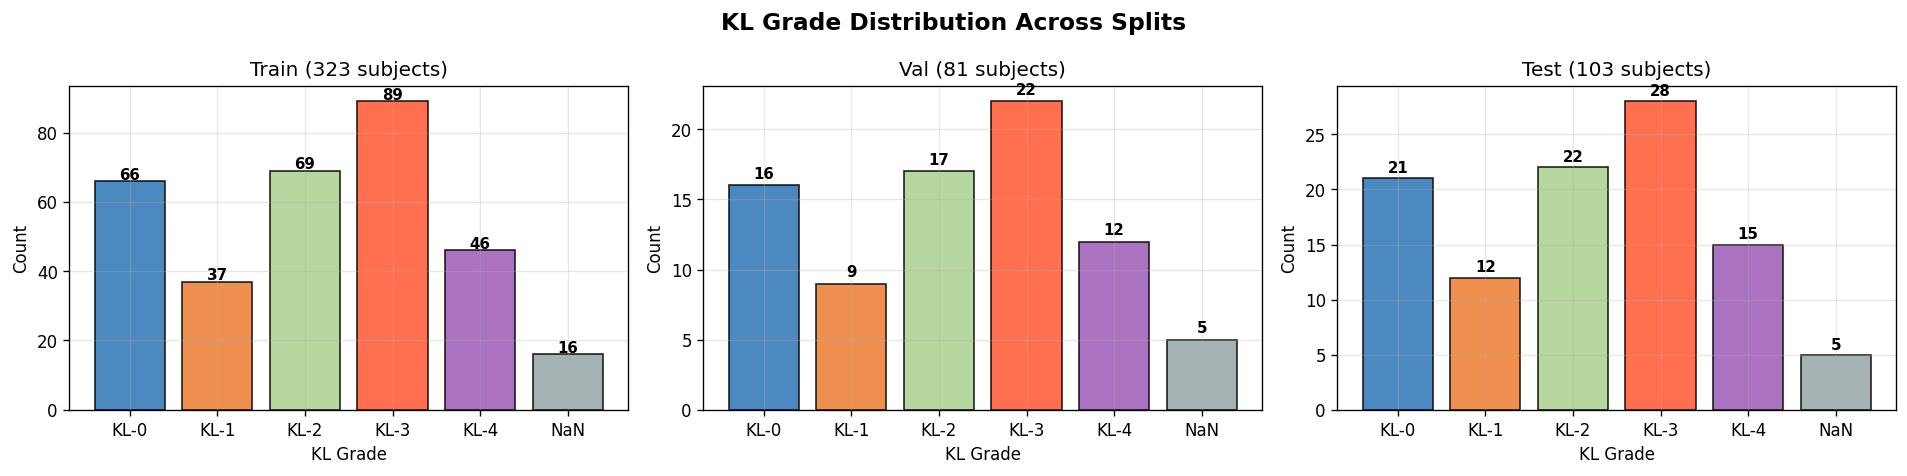

Age     : mean=61.9 ± 9.3  [45–79]
BMI     : mean=29.3 ± 4.5
Gender  : {'2': 245, '1': 262}
KneeSide: {'RIGHT': 507}


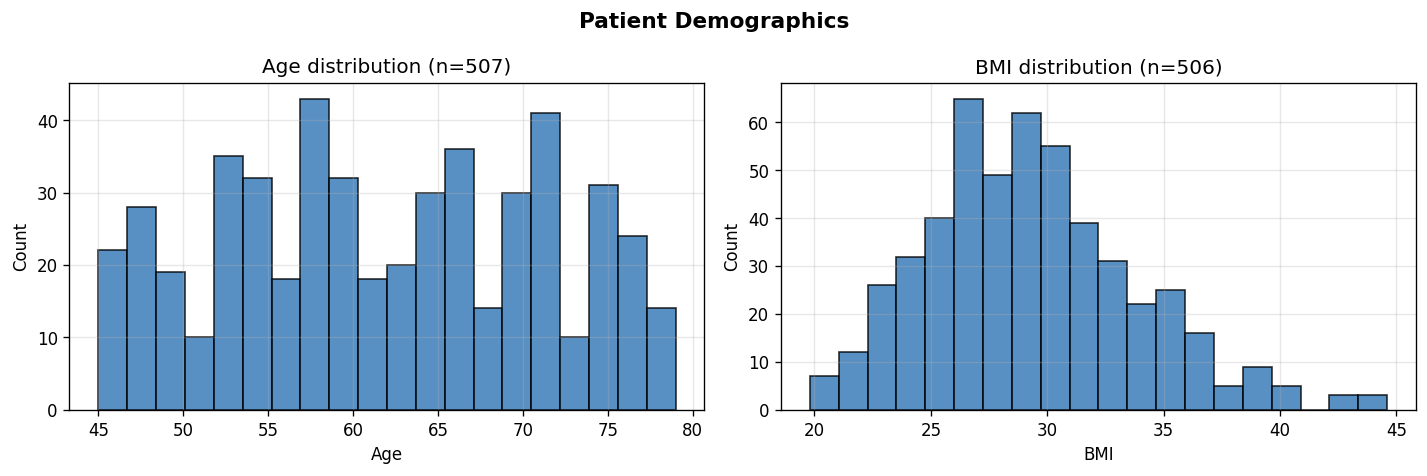


✅ EDA complete


In [6]:
# ─── KL Grade distributions ────────────────────────────────────────────────────
splits = {"Train": train_dicts, "Val": val_dicts, "Test": test_dicts}
kl_all = {}
for sname, dicts in splits.items():
    grades = [d.get("kl_grade", -1) for d in dicts]
    kl_all[sname] = Counter(grades)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
grade_labels = [0, 1, 2, 3, 4, -1]
for ax, (sname, counter) in zip(axes, kl_all.items()):
    vals  = [counter.get(g, 0) for g in grade_labels]
    xlabs = ["KL-0","KL-1","KL-2","KL-3","KL-4","NaN"]
    colors = ["#2E75B6","#ED7D31","#A9D18E","#FF5733","#9B59B6","#95A5A6"]
    ax.bar(xlabs, vals, color=colors, edgecolor="black", alpha=0.85)
    ax.set_title(f"{sname} ({sum(vals)} subjects)", fontsize=12)
    ax.set_xlabel("KL Grade"); ax.set_ylabel("Count")
    for i,(x,v) in enumerate(zip(xlabs, vals)):
        if v > 0: ax.text(i, v+0.5, str(v), ha="center", fontsize=9, fontweight="bold")
plt.suptitle("KL Grade Distribution Across Splits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "kl_distribution.png"), dpi=150)
plt.show()

# ─── Demographics ─────────────────────────────────────────────────────────────
all_info = train_dicts + val_dicts + test_dicts
ages    = [d["age"]  for d in all_info if d.get("age", -1) > 0]
bmis    = [d["bmi"]  for d in all_info if d.get("bmi", -1) > 0]
genders = Counter(d.get("gender","?") for d in all_info)
sides   = Counter(d.get("knee_side","?") for d in all_info)

print(f"Age     : mean={np.mean(ages):.1f} ± {np.std(ages):.1f}  "
      f"[{np.min(ages):.0f}–{np.max(ages):.0f}]")
print(f"BMI     : mean={np.mean(bmis):.1f} ± {np.std(bmis):.1f}")
print(f"Gender  : {dict(genders)}")
print(f"KneeSide: {dict(sides)}")

# Age & BMI by KL grade
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat, name in zip(axes, [ages, bmis], ["Age", "BMI"]):
    ax.hist(feat, bins=20, color="#2E75B6", edgecolor="black", alpha=0.8)
    ax.set_title(f"{name} distribution (n={len(feat)})"); ax.set_xlabel(name); ax.set_ylabel("Count")
plt.suptitle("Patient Demographics", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n✅ EDA complete")


## Cell 6 — CLAIR-Knee Atlas Loading [NEW]

The **CLAIR-Knee-103R** atlas provides:
- **Image** (64×128×128): MRI intensity template for alignment reference
- **Segmentation** (64×128×128, 6 labels): anatomical priors for knee structures

| Label | Tissue |
|-------|--------|
| 0 | Background |
| 1 | Femur Bone |
| 2 | Femoral Cartilage (FC) |
| 3 | Tibia Bone |
| 4 | Tibial Cartilage Medial (TC-M) |
| 5 | Tibial Cartilage Lateral (TC-L) |

Voxel spacing: **(1.4 × 0.729 × 0.729) mm**


Atlas image  : shape=(64, 128, 128)  min=0.0  max=20.0
Atlas seg    : shape=(64, 128, 128)  labels=[0, 1, 2, 3, 4, 5]
Voxel spacing: (1.4, 0.7292, 0.7292) mm


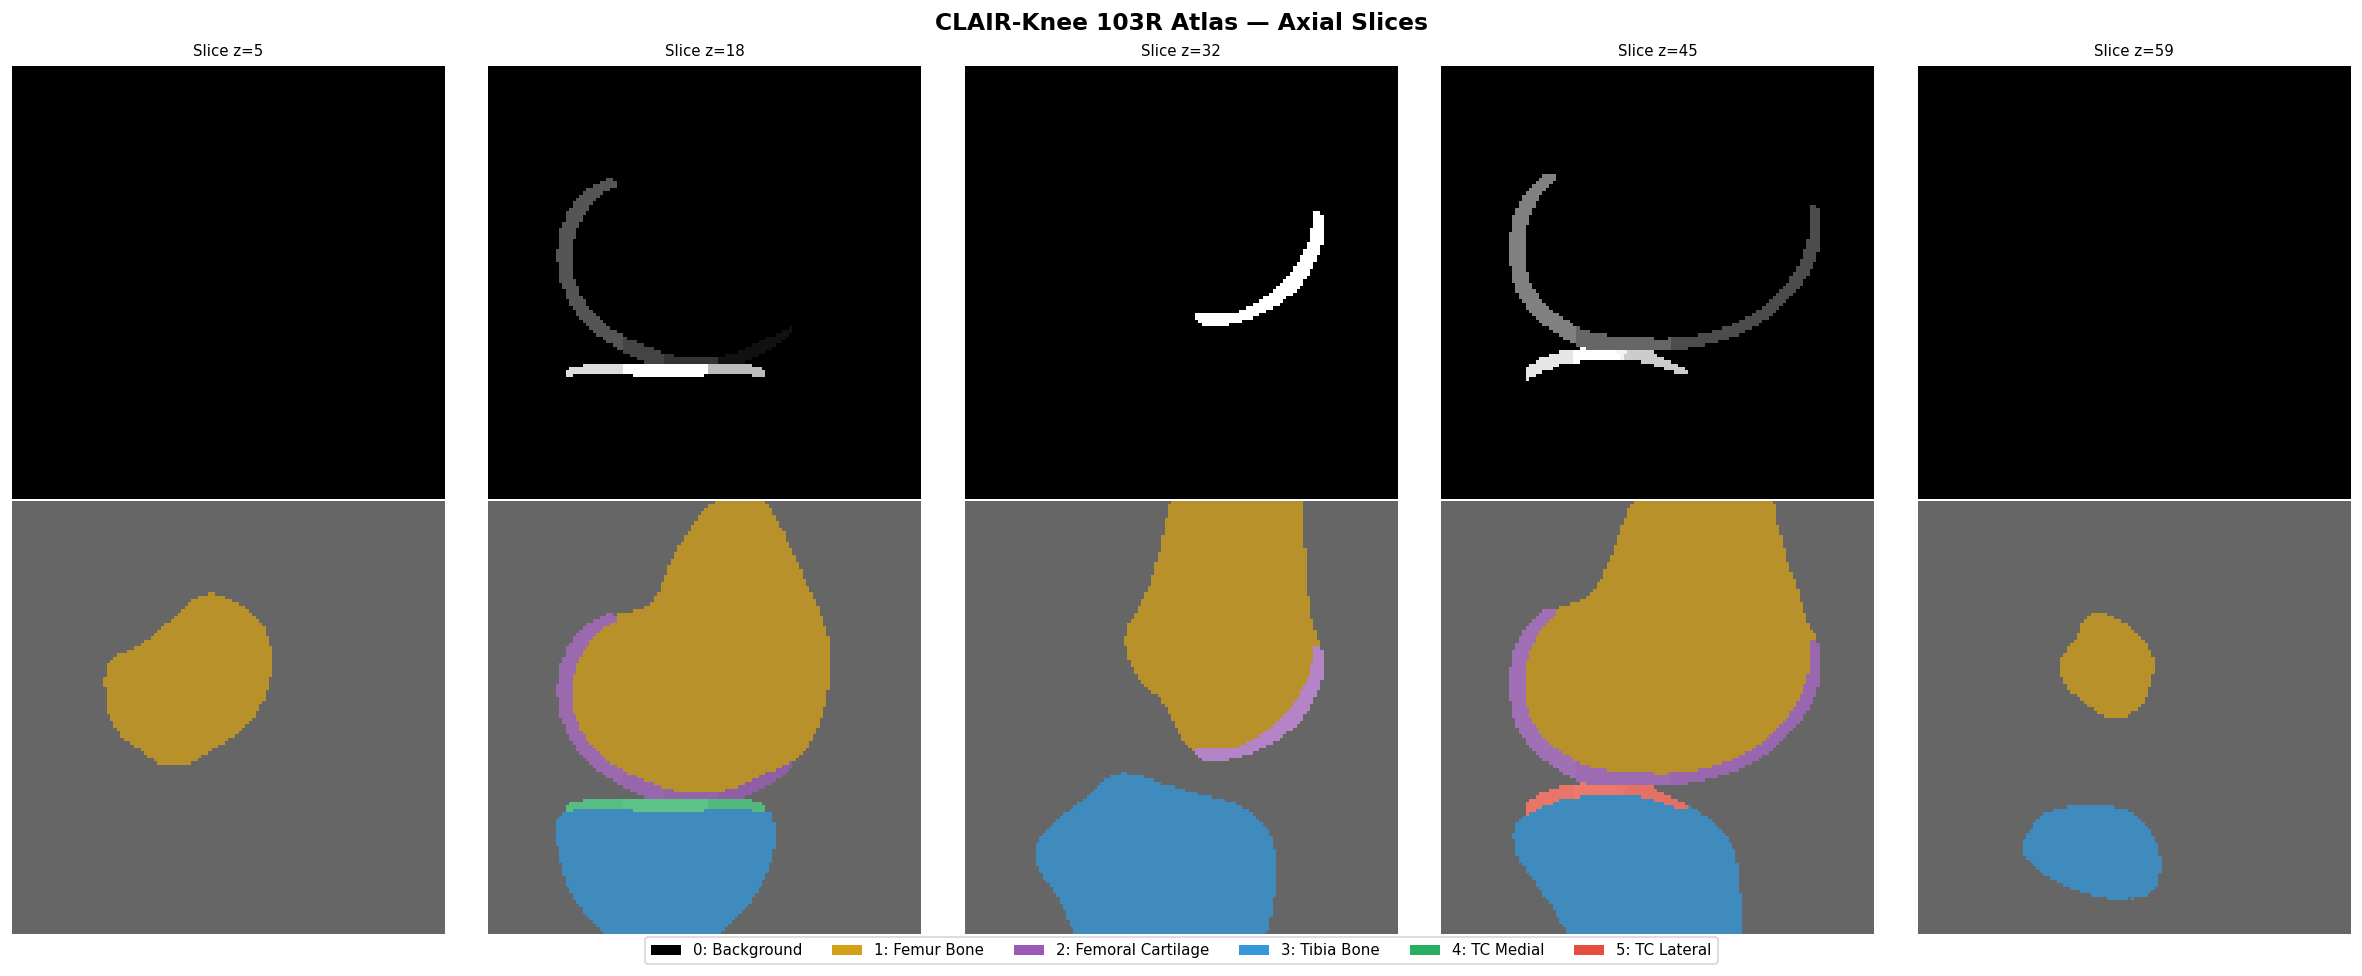

  Label 1 (Femur Bone               ): 155.15 mL
  Label 2 (Femoral Cartilage        ): 12.65 mL
  Label 3 (Tibia Bone               ): 82.05 mL
  Label 4 (TC Medial                ): 1.78 mL
  Label 5 (TC Lateral               ): 1.88 mL

✅ Atlas loaded and visualised


In [7]:
# ─── Load atlas NIfTI files ───────────────────────────────────────────────────

def load_atlas(img_path: str, seg_path: str):
    """Load CLAIR-Knee atlas image and segmentation, return numpy arrays."""
    atlas_img_nib = nib.load(img_path)
    atlas_seg_nib = nib.load(seg_path)

    atlas_img = atlas_img_nib.get_fdata().astype(np.float32)   # (64,128,128)
    atlas_seg = atlas_seg_nib.get_fdata().astype(np.int32)     # (64,128,128)
    spacing   = atlas_img_nib.header.get_zooms()                # (z,y,x) in mm

    return atlas_img, atlas_seg, spacing


ATLAS_LABEL_MAP = {
    0: ("Background",              "#000000"),
    1: ("Femur Bone",              "#D4A017"),
    2: ("Femoral Cartilage",       "#9B59B6"),
    3: ("Tibia Bone",              "#3498DB"),
    4: ("TC Medial",               "#27AE60"),
    5: ("TC Lateral",              "#E74C3C"),
}

atlas_img, atlas_seg, atlas_spacing = load_atlas(cfg.atlas_img_path, cfg.atlas_seg_path)
print(f"Atlas image  : shape={atlas_img.shape}  min={atlas_img.min():.1f}  max={atlas_img.max():.1f}")
print(f"Atlas seg    : shape={atlas_seg.shape}  labels={np.unique(atlas_seg).tolist()}")
print(f"Voxel spacing: {atlas_spacing} mm")

# ─── Visualise atlas ──────────────────────────────────────────────────────────
atlas_cmap = ListedColormap([v[1] for v in ATLAS_LABEL_MAP.values()])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
z_slices = np.linspace(5, atlas_img.shape[0]-5, 5).astype(int)

for col, zs in enumerate(z_slices):
    axes[0, col].imshow(atlas_img[zs].T, cmap="gray", origin="lower")
    axes[0, col].set_title(f"Slice z={zs}", fontsize=9)
    axes[0, col].axis("off")

    seg_slice = atlas_seg[zs]
    axes[1, col].imshow(atlas_img[zs].T, cmap="gray", origin="lower", alpha=0.6)
    overlay = np.ma.masked_where(seg_slice.T == 0, seg_slice.T)
    axes[1, col].imshow(overlay, cmap=atlas_cmap, vmin=0, vmax=5,
                         origin="lower", alpha=0.75)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Image", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Seg Overlay", fontsize=11, fontweight="bold")

# Legend
patches = [mpatches.Patch(facecolor=v[1], label=f"{k}: {v[0]}")
           for k, v in ATLAS_LABEL_MAP.items()]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle("CLAIR-Knee 103R Atlas — Axial Slices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "clair_atlas.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── Atlas-based cartilage volume priors (for atlas-guided analysis in Cell 34) ─
atlas_vol_priors = {}
vox_vol = float(np.prod(atlas_spacing))
for lab, (name, _) in ATLAS_LABEL_MAP.items():
    if lab == 0: continue
    vol_ml = float((atlas_seg == lab).sum() * vox_vol / 1000.0)
    atlas_vol_priors[lab] = {"name": name, "vol_ml": vol_ml}
    print(f"  Label {lab} ({name:25s}): {vol_ml:.2f} mL")

print("\n✅ Atlas loaded and visualised")


## Cell 7 — NIfTI Transforms (MONAI + TorchIO)

In [8]:
# ─── (A) Extraction transforms — for patch pre-extraction (uses LoadImaged) ───
def get_extraction_transforms(cfg: Config):
    """MONAI transforms used during patch pre-extraction."""
    return Compose([
        LoadImaged(keys=["image","label"], image_only=False, ensure_channel_first=True),
        Orientationd(keys=["image","label"], axcodes="RAS"),
        Spacingd(keys=["image","label"],
                 pixdim=list(cfg.voxel_spacing),
                 mode=("bilinear","nearest")),
        ScaleIntensityRangePercentilesd(
            keys=["image"], lower=1, upper=99,
            b_min=0.0, b_max=1.0, clip=True),
        RandCropByPosNegLabeld(
            keys=["image","label"],
            label_key="label",
            spatial_size=cfg.img_size,
            pos=3, neg=1,
            num_samples=cfg.patches_per_subj,
            allow_smaller=True),
        ToTensord(keys=["image","label"]),
    ])


# ─── (B) TorchIO transforms — for RAVE inference pipeline ─────────────────────
def get_transforms(train: bool = False) -> tio.Compose:
    """
    TorchIO-compatible transform chain.
    NIfTI files are read natively by TorchIO — no custom reader needed.
    """
    base = [
        tio.transforms.RescaleIntensity(percentiles=(1, 99), out_min_max=(0, 1)),
    ]
    if train:
        aug = [
            tio.RandomFlip(axes=(0,1,2), flip_probability=0.5),
            tio.RandomAffine(scales=(0.9,1.1), degrees=10, p=0.4),
            tio.RandomGamma(log_gamma_range=(-0.3,0.3), p=0.3),
            tio.RandomNoise(mean=0, std=0.05, p=0.3),
        ]
        return tio.Compose(base + aug)
    return tio.Compose(base)

print("✅ Transforms defined (MONAI LoadImaged + TorchIO)")
print(f"   Extraction: LoadImaged → Orientation → Spacing → ScalePercentile → RandCrop")
print(f"   Inference : TorchIO Compose (RescaleIntensity + optional augmentation)")


✅ Transforms defined (MONAI LoadImaged + TorchIO)
   Extraction: LoadImaged → Orientation → Spacing → ScalePercentile → RandCrop
   Inference : TorchIO Compose (RescaleIntensity + optional augmentation)


## Cell 8 — Load TorchIO Subjects (NIfTI Native)

**Key change**: No `reader=fast_npy_reader`.  
TorchIO reads `.nii.gz` natively via nibabel — just pass the path directly.


In [9]:
def load_tio_subjects(data_dicts: List[dict]) -> List[tio.Subject]:
    """
    Build TorchIO Subject objects from data dicts.
    NIfTI files are read natively — no custom reader argument.
    Missing files are skipped with a warning.
    """
    subjects = []
    n_missing = 0
    for d in data_dicts:
        img_path = d["image"]
        lbl_path = d["label"]
        if not os.path.exists(img_path):
            print(f"  ⚠  Missing image: {img_path}")
            n_missing += 1
            continue
        subj = tio.Subject(
            image=tio.ScalarImage(img_path),   # .nii.gz — TorchIO handles it
            label=tio.LabelMap(lbl_path),
            subject_id = d.get("subject_id", ""),
            cmt_id     = d.get("cmt_id", -1),
            kl_grade   = d.get("kl_grade", -1),
            age        = d.get("age", -1.0),
            bmi        = d.get("bmi", -1.0),
            gender     = d.get("gender", "?"),
            knee_side  = d.get("knee_side", "?"),
            split      = d.get("split", ""),
        )
        subjects.append(subj)
    if n_missing:
        print(f"  ⚠  {n_missing} subjects skipped (missing NIfTI files)")
    return subjects


print("Loading TorchIO subjects …")
train_subjects = load_tio_subjects(train_dicts)
val_subjects   = load_tio_subjects(val_dicts)
test_subjects  = load_tio_subjects(test_dicts)

print(f"\n  Train subjects : {len(train_subjects)}")
print(f"  Val subjects   : {len(val_subjects)}")
print(f"  Test subjects  : {len(test_subjects)}")

# Inspect first subject
if train_subjects:
    s = train_subjects[0]
    print(f"\nSample subject  : {s.subject_id}")
    print(f"  Image shape   : {s.image.shape}")
    print(f"  Label shape   : {s.label.shape}")
    print(f"  KL grade      : {s.kl_grade}")
    print(f"  Age / BMI     : {s.age} / {s.bmi}")
    print(f"  Knee side     : {s.knee_side}")


Loading TorchIO subjects …

  Train subjects : 323
  Val subjects   : 81
  Test subjects  : 103

Sample subject  : oaizib_132
  Image shape   : (1, 160, 384, 384)
  Label shape   : (1, 160, 384, 384)
  KL grade      : 2
  Age / BMI     : 72.0 / 32.6
  Knee side     : RIGHT


## Cell 9 — Label Sanity Check (NIfTI-Aware)

In [10]:
# ─── Check label semantics on a few NIfTI files ───────────────────────────────
print("─── CARTILAGE LABEL SANITY CHECK (NIfTI) ───")
voxel_vol_mm3 = float(np.prod(cfg.voxel_spacing))

LABEL_GUESS = {
    0: "Background",
    1: "Femur",
    2: "Femoral Cartilage",
    3: "Tibia",
    4: "Medial Tibial Cartilage",
    5: "Lateral Tibial Cartilage",
}

for d in train_dicts[:3]:
    lbl_path = d["label"]
    if not os.path.exists(lbl_path):
        print(f"  SKIP (not found): {lbl_path}"); continue

    nii  = nib.load(lbl_path)
    lbl  = nii.get_fdata().astype(np.int32)
    spacing = nii.header.get_zooms()
    voxvol  = float(np.prod(spacing))

    print(f"\nFile    : {os.path.basename(lbl_path)}")
    print(f"Shape   : {lbl.shape}  |  Spacing: {[round(s,3) for s in spacing]} mm")
    print(f"Labels  : {np.unique(lbl).tolist()}")

    for v in np.unique(lbl):
        count  = int((lbl == v).sum())
        vol_ml = count * voxvol / 1000.0
        guess  = LABEL_GUESS.get(v, "?")
        print(f"  [{v}] {guess:35s}  voxels={count:7d}  vol={vol_ml:.2f} mL")

# ─── Compare with atlas label sizes ───────────────────────────────────────────
print("\n─── Atlas label volumes (reference) ───")
for lab, info in atlas_vol_priors.items():
    print(f"  [{lab}] {info['name']:25s}: {info['vol_ml']:.2f} mL")

print("\n✅ Label sanity check complete")


─── CARTILAGE LABEL SANITY CHECK (NIfTI) ───

File    : oaizib_132.nii
Shape   : (160, 384, 384)  |  Spacing: [0.7, 0.365, 0.365] mm
Labels  : [0, 1, 2, 3, 4, 5]
  [0] Background                           voxels=20663592  vol=1922.64 mL
  [1] Femur                                voxels=1552156  vol=144.42 mL
  [2] Femoral Cartilage                    voxels= 155047  vol=14.43 mL
  [3] Tibia                                voxels=1175373  vol=109.36 mL
  [4] Medial Tibial Cartilage              voxels=  21210  vol=1.97 mL
  [5] Lateral Tibial Cartilage             voxels=  25582  vol=2.38 mL

File    : oaizib_183.nii
Shape   : (160, 384, 384)  |  Spacing: [0.7, 0.365, 0.365] mm
Labels  : [0, 1, 2, 3, 4, 5]
  [0] Background                           voxels=20821239  vol=1937.31 mL
  [1] Femur                                voxels=1549111  vol=144.14 mL
  [2] Femoral Cartilage                    voxels= 141976  vol=13.21 mL
  [3] Tibia                                voxels=1046513  vol=97.

## Cell 10 — Pre-Extract Training Patches *(run once)*

Saves patches as float16 NPZ files. Uses **MONAI `LoadImaged`** (replaces old `LoadNpyd`).


In [11]:
def preextract_patches(
    train_dicts: List[dict],
    cfg:         Config,
    force:       bool = False,
) -> List[str]:

    out      = Path(cfg.patch_cache_dir)
    idx_file = out / "index.json"

    # ── FIXED skip-logic: only skip if patches actually exist on disk ─────────
    if idx_file.exists() and not force:
        with open(idx_file) as f:
            existing = json.load(f)

        # Verify files are physically present (not just listed in the index)
        valid = [p for p in existing if os.path.exists(p)]

        if len(valid) > 0:
            print(f"✅ Found {len(valid)} pre-extracted patches — skipping.")
            print(f"   Index : {idx_file}")
            print("   Pass force=True to re-extract.")
            return valid

        # index.json exists but is empty or points to deleted files → re-extract
        if len(existing) == 0:
            print("⚠  index.json exists but contains 0 entries — re-extracting.")
        else:
            print(f"⚠  index.json lists {len(existing)} patches but 0 exist on disk.")
            print("   Patch files may have been deleted or cache_dir changed.")
            print("   Re-extracting now …")

    # ── (rest of the function is unchanged) ───────────────────────────────────
    out.mkdir(parents=True, exist_ok=True)

    patch_tfm = Compose([
        LoadImaged(keys=["image","label"], image_only=False, ensure_channel_first=True),
        Orientationd(keys=["image","label"], axcodes="RAS"),
        Spacingd(keys=["image","label"],
                 pixdim=list(cfg.voxel_spacing),
                 mode=("bilinear","nearest")),
        ScaleIntensityRangePercentilesd(
            keys=["image"], lower=1, upper=99,
            b_min=0.0, b_max=1.0, clip=True),
        RandCropByPosNegLabeld(
            keys=["image","label"],
            label_key="label",
            spatial_size=cfg.img_size,
            pos=3, neg=1,
            num_samples=cfg.patches_per_subj,
            allow_smaller=True),
    ])

    patch_index, total_size, failed = [], 0, []

    # Count available subjects before starting
    available = [d for d in train_dicts if os.path.exists(d.get("image", ""))]
    print(f"Extracting patches: {len(available)} valid subjects "
          f"({len(train_dicts) - len(available)} missing files skipped)")
    if len(available) == 0:
        raise FileNotFoundError(
            "No NIfTI files found in train_dicts.\n"
            f"  Sample path checked: {train_dicts[0].get('image','') if train_dicts else 'empty'}\n"
            "  → Fix cfg.base_dir in Cell 3 Config to point to your actual dataset folder.")

    for d in tqdm(available, desc="Extracting patches"):
        sid = d.get("subject_id", "unknown")
        try:
            patches = patch_tfm({"image": d["image"], "label": d["label"]})
            if not isinstance(patches, list):
                patches = [patches]
            for p_idx, patch in enumerate(patches):
                img = patch["image"]
                lbl = patch["label"]
                if hasattr(img, "numpy"): img = img.numpy()
                if hasattr(lbl, "numpy"): lbl = lbl.numpy()
                fname = out / f"{sid}_patch{p_idx:03d}.npz"
                np.savez_compressed(str(fname),
                    image=img.astype(np.float16),
                    label=lbl.astype(np.uint8))
                patch_index.append(str(fname))
                total_size += fname.stat().st_size
        except Exception as e:
            print(f"  ✗ {sid}: {e}")
            failed.append(sid)

    with open(idx_file, "w") as f:
        json.dump(patch_index, f)

    print(f"\n✅ Extracted {len(patch_index)} patches  |  "
          f"Disk: {total_size/1e9:.2f} GB")
    if failed:
        print(f"   Failed ({len(failed)}): {failed[:5]}")
    return patch_index

# ── Run (set force=True to re-extract) ───────────────────────────────────────
patch_files = preextract_patches(train_dicts, cfg, force=False)


Extracting patches: 323 valid subjects (0 missing files skipped)


Extracting patches: 100%|██████████| 323/323 [11:21<00:00,  2.11s/it]


✅ Extracted 969 patches  |  Disk: 3.33 GB


## Cell 11 — PatchCacheDataset

In [12]:
class PatchCacheDataset(Dataset):
    """
    Ultra-fast Dataset serving pre-extracted patches from float16 NPZ files.
    Augmentation applied per __getitem__ (no TorchIO overhead).
    """
    def __init__(self, patch_dir: str, augment: bool = True, augment_prob: float = 0.5):
        idx_file = Path(patch_dir) / "index.json"
        if not idx_file.exists():
            raise FileNotFoundError(
                f"Patch index not found: {idx_file}\n"
                "Run preextract_patches() first (Cell 10).")
        with open(idx_file) as f:
            self.paths = json.load(f)
        self.augment      = augment
        self.augment_prob = augment_prob
        print(f"PatchCacheDataset: {len(self.paths)} patches from {patch_dir}")

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        data = np.load(self.paths[idx])
        img  = data["image"].astype(np.float32)
        lbl  = data["label"].astype(np.int64)

        img_t = torch.from_numpy(img.copy())
        lbl_t = torch.from_numpy(lbl.copy())

        if self.augment:
            for ax in range(3):
                if np.random.random() < self.augment_prob:
                    img_t = torch.flip(img_t, dims=[ax+1])
                    lbl_t = torch.flip(lbl_t, dims=[ax+1])

        return {"image": img_t, "label": lbl_t}


train_ds = PatchCacheDataset(cfg.patch_cache_dir, augment=True)
print(f"✅ PatchCacheDataset ready: {len(train_ds)} patches")


PatchCacheDataset: 969 patches from D:/ishtiaque/Knee segementation/patch_cache
✅ PatchCacheDataset ready: 969 patches


## Cell 12 — Validation Volume Dataset & DataLoaders

In [13]:
class ValVolumeDataset(Dataset):
    """
    Loads full NIfTI volumes via nibabel for validation.
    Returns plain tensors — no TorchIO in training loop.
    """
    def __init__(self, data_dicts: List[dict], cfg: Config):
        self.dicts = [d for d in data_dicts if os.path.exists(d["image"])]
        self.cfg   = cfg

    def __len__(self): return len(self.dicts)

    def __getitem__(self, idx):
        d   = self.dicts[idx]
        img = nib.load(d["image"]).get_fdata().astype(np.float32)
        lbl = nib.load(d["label"]).get_fdata().astype(np.float32)

        if img.ndim == 3: img = img[np.newaxis]   # (H,W,D) → (1,H,W,D)
        if lbl.ndim == 3: lbl = lbl[np.newaxis]

        # Percentile 1–99 normalisation
        p1, p99 = np.percentile(img, [1, 99])
        img = np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

        return {
            "image":      torch.from_numpy(img.copy()),
            "label":      torch.from_numpy(lbl.copy()),
            "subject_id": d.get("subject_id", ""),
        }


val_ds     = ValVolumeDataset(val_dicts, cfg)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                          shuffle=True, num_workers=cfg.num_workers,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

print(f"Train DataLoader: {len(train_loader)} batches  (batch_size={cfg.batch_size})")
print(f"Val   DataLoader: {len(val_loader)} volumes")


Train DataLoader: 969 batches  (batch_size=1)
Val   DataLoader: 81 volumes


## Cell 13 — SwinUNETR Lightning Module

In [14]:
import inspect
from monai.utils import BlendMode

_swin_params = inspect.signature(SwinUNETR.__init__).parameters
_swin_kwargs = dict(
            in_channels    = 1,
            out_channels   = cfg.num_classes,
            feature_size   = cfg.feature_size,
            depths         = cfg.swin_depths,
            num_heads      = cfg.swin_num_heads,
            use_checkpoint = cfg.use_checkpoint,
            spatial_dims   = cfg.spatial_dims,
            drop_rate      = cfg.drop_rate,
        )
if "img_size"          in _swin_params: _swin_kwargs["img_size"]          = cfg.img_size
if "use_v2"            in _swin_params: _swin_kwargs["use_v2"]            = cfg.use_v2
if "attn_drop_rate"    in _swin_params: _swin_kwargs["attn_drop_rate"]    = cfg.attn_drop_rate
if "dropout_path_rate" in _swin_params: _swin_kwargs["dropout_path_rate"] = cfg.drop_rate


class SwinUNETRModule(pl.LightningModule):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg         = cfg
        self.model       = SwinUNETR(**_swin_kwargs)
        self.loss_fn     = DiceCELoss(to_onehot_y=True, softmax=True,
                                       include_background=False)
        self.dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
        self.post_pred   = Compose([EnsureType(),
                                    AsDiscrete(argmax=True, to_onehot=cfg.num_classes)])
        self.post_label  = Compose([EnsureType(),
                                    AsDiscrete(to_onehot=cfg.num_classes)])
        self.inferer = SlidingWindowInferer(
            roi_size=cfg.img_size, sw_batch_size=2, overlap=0.5,
            mode="gaussian" if any(m.value=="gaussian"
                                   for m in BlendMode) else "constant")

    def forward(self, x):    return self.model(x)
    
    @torch.no_grad()
    def extract_embedding(self, x):
        """Extract 768-d stage-4 features (used by RAVE)."""
        # feats = self.model.swinViT(x, normalize=True)
        # emb   = feats[4].mean(dim=[2,3,4]).cpu().numpy()
        feats = self.model.swinViT(x, self.model.normalize)
        emb   = feats[3].mean(dim=[2, 3, 4]).cpu().numpy()
        return emb.squeeze()

    def _step(self, batch, stage: str = "train") -> torch.Tensor:
        # Handle both PatchCacheDataset (plain tensor) and ValVolumeDataset
        imgs = batch["image"] if isinstance(batch, dict) else batch[0]
        lbls = batch["label"] if isinstance(batch, dict) else batch[1]
        if imgs.dtype != torch.float32: imgs = imgs.float()
        if lbls.dtype != torch.float32: lbls = lbls.float()

        logits = self(imgs)
        loss   = self.loss_fn(logits, lbls.long())

        if stage == "val":
            preds = self.inferer(imgs, self)
            preds_dec = [self.post_pred(i)  for i in decollate_batch(preds)]
            lbls_dec  = [self.post_label(i) for i in decollate_batch(lbls)]
            self.dice_metric(preds_dec, lbls_dec)

        self.log(f"{stage}/loss", loss, prog_bar=True, sync_dist=True)
        return loss

    def training_step(self, batch, _): return self._step(batch, "train")

    def validation_step(self, batch, _): self._step(batch, "val")

    def on_validation_epoch_end(self):
        dice = self.dice_metric.aggregate()
        mean = dice.mean().item()
        self.log("val/dice", mean, prog_bar=True, sync_dist=True)
        for i, c in enumerate(cfg.class_names[1:]):
            self.log(f"val/dice_{c[:8]}", dice[i].item())
        self.dice_metric.reset()

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(),
                                lr=cfg.lr, weight_decay=cfg.weight_decay)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=cfg.num_epochs, eta_min=cfg.lr/100)
        return {"optimizer": opt, "lr_scheduler": sch}


model = SwinUNETRModule(cfg)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"SwinUNETR: {total_params:.1f}M parameters")


SwinUNETR: 62.2M parameters


## Cell 14 — Train SwinUNETR

In [15]:
# import os

# # Tell CUDA to report errors at the exact kernel that caused them
# os.environ["CUDA_LAUNCH_BLOCKING"] = "0"   # keep 0 for speed; set 1 only when debugging

# torch.set_float32_matmul_precision("high")  # RTX 5090 Tensor Cores

# checkpoint_cb = pl.callbacks.ModelCheckpoint(
#     monitor   = "val/dice",
#     mode      = "max",
#     save_top_k = 2,
#     filename  = "hybrid-swin-{epoch:02d}-dice{val/dice:.4f}",
# )
# lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval="epoch")

# trainer = pl.Trainer(
#     max_epochs             = cfg.num_epochs,
#     accelerator            = "gpu",
#     devices                = 1,
#     precision              = "16-mixed",      # AMP: cuts kernel time ~2×
#     strategy               = "auto",
#     callbacks              = [checkpoint_cb, lr_monitor],
#     log_every_n_steps      = 10,
#     gradient_clip_val      = 1.0,
#     accumulate_grad_batches = 2,              # effective bs=2 without larger kernels
#     check_val_every_n_epoch = cfg.check_val_every,   # validate less often
#     num_sanity_val_steps   = 1,              # was 2 — shorten startup validation
#     enable_progress_bar    = True,
#     deterministic          = False,           # True adds overhead → longer kernels
# )

# print(f"RTX 5090 detected : {torch.cuda.get_device_name(0)}")
# print(f"VRAM available    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
# print(f"Precision         : 16-mixed  (AMP)")
# print(f"Sliding overlap   : {cfg.val_overlap}  (was 0.5)")
# print(f"Validate every    : {cfg.check_val_every} epochs")

# trainer.fit(model, train_loader, val_loader)

In [16]:
checkpoint_cb = ModelCheckpoint(
    dirpath=cfg.output_dir,
    filename="swinunetr-{epoch:03d}-{val/dice:.4f}",
    monitor="val/dice", mode="max", save_top_k=3, save_last=True,
)
lr_monitor = LearningRateMonitor(logging_interval="epoch")

trainer = pl.Trainer(
    max_epochs        = cfg.num_epochs,
    accelerator       = "gpu" if torch.cuda.is_available() else "cpu",
    devices           = 1,
    precision         = "16-mixed" if torch.cuda.is_available() else 32,
    callbacks         = [checkpoint_cb, lr_monitor],
    log_every_n_steps = 10,
    val_check_interval= 1.0,
    gradient_clip_val = 1.0,
)

print(f"Starting training: {cfg.num_epochs} epochs | {len(train_loader)} steps/epoch")
trainer.fit(model, train_loader, val_loader)
print(f"\n✅ Training complete")
print(f"   Best checkpoint: {checkpoint_cb.best_model_path}")
print(f"   Best val Dice  : {checkpoint_cb.best_model_score:.4f}")


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
Missing logger folder: d:\ishtiaque\Knee segementation\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting training: 40 epochs | 969 steps/epoch



  | Name    | Type       | Params
---------------------------------------
0 | model   | SwinUNETR  | 62.2 M
1 | loss_fn | DiceCELoss | 0     
---------------------------------------
62.2 M    Trainable params
0         Non-trainable params
62.2 M    Total params
248.748   Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.



✅ Training complete
   Best checkpoint: D:\ishtiaque\Knee segementation\rave_output\swinunetr-epoch=012-val/dice=0.5898.ckpt
   Best val Dice  : 0.5898


## Cell 15 — Load Best Checkpoint

In [17]:
def load_best_model(cfg: Config, device, checkpoint_cb=None) -> SwinUNETRModule:
    """
    Load the best SwinUNETRModule checkpoint, with three fallback levels:
      1. checkpoint_cb.best_model_path (set by Lightning during training)
      2. cfg.output_dir/last.ckpt
      3. Any *.ckpt found in cfg.output_dir (sorted by mtime, newest first)
    If no checkpoint exists the freshly initialised model is returned with a
    warning.  Loads via state_dict to avoid dependency on module-level globals.
    """
    import glob

    candidate_paths = []
    if checkpoint_cb is not None and getattr(checkpoint_cb, "best_model_path", ""):
        candidate_paths.append(checkpoint_cb.best_model_path)
    candidate_paths.append(os.path.join(cfg.output_dir, "last.ckpt"))
    # Any other checkpoints in output_dir, newest first
    extra = sorted(
        glob.glob(os.path.join(cfg.output_dir, "*.ckpt")),
        key=os.path.getmtime, reverse=True
    )
    candidate_paths.extend(extra)

    fresh_model = SwinUNETRModule(cfg).to(device)

    for ckpt_path in candidate_paths:
        if not ckpt_path or not os.path.exists(ckpt_path):
            continue
        try:
            ckpt = torch.load(ckpt_path, map_location=device)
            # Lightning saves under key 'state_dict'; raw torch.save gives the
            # dict directly
            state_dict = ckpt.get("state_dict", ckpt)
            missing, unexpected = fresh_model.load_state_dict(state_dict, strict=True)
            if missing:
                print(f"  ⚠  Missing keys ({len(missing)}): {missing[:5]}")
            if unexpected:
                print(f"  ⚠  Unexpected keys ({len(unexpected)}): {unexpected[:5]}")
            fresh_model.eval()
            print(f"✅ Checkpoint loaded: {ckpt_path}")
            return fresh_model
        except Exception as e:
            print(f"  ✗  Failed to load {ckpt_path}: {e}")
            continue

    print("⚠  No valid checkpoint found — using random weights.")
    print("   Embeddings will be uninformative until a checkpoint is trained/provided.")
    fresh_model.eval()
    return fresh_model


model = load_best_model(cfg, device,
                        checkpoint_cb=checkpoint_cb if "checkpoint_cb" in dir() else None)
model = model.to(device)

# Quick inference smoke-test on first val subject
if val_subjects:
    tfm  = get_transforms(train=False)
    subj = tfm(val_subjects[0])
    vol  = subj.image.data.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model.inferer(vol, model)
    pred = logits.argmax(dim=1).squeeze().cpu().numpy()
    emb_test = model.extract_embedding(vol[:, :, :96, :96, :96])
    print(f"\nInference smoke-test :")
    print(f"  input       : {tuple(vol.shape)}")
    print(f"  pred labels : {np.unique(pred).tolist()}")
    print(f"  embedding   : shape={emb_test.shape}  norm={np.linalg.norm(emb_test):.4f}")
    assert np.linalg.norm(emb_test) > 1e-3, \
        "⚠  Embedding norm ≈ 0 — model may not be loaded correctly!"
    print("✅ Model loaded and embedding is non-zero")

✅ Checkpoint loaded: D:\ishtiaque\Knee segementation\rave_output\swinunetr-epoch=012-val/dice=0.5898.ckpt

Inference smoke-test :
  input       : (1, 1, 160, 384, 384)
  pred labels : [0, 1, 2, 3, 4, 5]
  embedding   : shape=(384,)  norm=18.9984
✅ Model loaded and embedding is non-zero


## Cell 16 — KL Grades from CSV

**Key change**: Old code used Excel (`subInfo_train/test.xlsx`) with `(SubjectID, BarcodeTail)` key.  
New code uses CSV with CMT-ID as the direct key (no barcode parsing needed).


In [18]:
def build_kl_lookup_from_csv(
    sub_info_train: str,
    sub_info_test:  str,
) -> Tuple[dict, bool]:
    """
    Build a lookup: CMT-ID (int) → { kl_grade, age, bmi, gender, knee_side, split }.
    Returns (lookup_dict, USE_REAL_KL).
    """
    try:
        si_tr = load_csv_with_bom(sub_info_train)
        si_ts = load_csv_with_bom(sub_info_test)
    except Exception as e:
        print(f"⚠  Cannot load subInfo CSVs: {e}")
        return {}, False

    df = pd.concat([
        si_tr.assign(split="train"),
        si_ts.assign(split="test"),
    ], ignore_index=True)

    lookup = {}
    nan_kl = 0
    for _, row in df.iterrows():
        cmt = int(row["CMT-ID"])
        kl  = int(row["KLGrade"]) if pd.notna(row.get("KLGrade")) else None
        if kl is None: nan_kl += 1
        lookup[cmt] = {
            "kl_grade":  kl,
            "age":       float(row["Age"])  if pd.notna(row.get("Age"))  else None,
            "bmi":       float(row["BMI"])  if pd.notna(row.get("BMI"))  else None,
            "gender":    str(row.get("Gender","?")).strip(),
            "knee_side": {1:"RIGHT",2:"LEFT"}.get(
                             int(row["KneeSide"]) if pd.notna(row.get("KneeSide")) else 0,
                             "UNKNOWN"),
            "split": str(row.get("split","?"))
        }

    use_real = len(lookup) > 0
    print(f"KL lookup built: {len(lookup)} subjects  |  NaN KL: {nan_kl}")
    return lookup, use_real


def get_kl_for_subject(subject_id: str, lookup: dict) -> Optional[int]:
    """
    subject_id 'oaizib_211' → CMT-ID 211 → lookup[211]['kl_grade'].
    Returns None if not found or KL is NaN.
    """
    m = re.search(r"oaizib_0*([1-9]\d*)", str(subject_id))
    if not m: return None
    cmt = int(m.group(1))
    entry = lookup.get(cmt)
    if entry is None: return None
    return entry.get("kl_grade")   # may be None for NaN KL subjects


# ── Execute ───────────────────────────────────────────────────────────────────
kl_lookup, USE_REAL_KL = build_kl_lookup_from_csv(
    cfg.sub_info_train_csv, cfg.sub_info_test_csv)

if USE_REAL_KL:
    # Augment subjects with KL grades
    for s in train_subjects + val_subjects + test_subjects:
        kl = get_kl_for_subject(s.subject_id, kl_lookup)
        s.kl_grade_real = kl   # add attribute

    grade_dist = Counter(
        v["kl_grade"] for v in kl_lookup.values() if v.get("kl_grade") is not None)
    print(f"\nKL distribution: {dict(sorted(grade_dist.items()))}")
    print(f"USE_REAL_KL = True ✅")


KL lookup built: 507 subjects  |  NaN KL: 26

KL distribution: {0: 103, 1: 58, 2: 108, 3: 139, 4: 73}
USE_REAL_KL = True ✅


## Cell 17 — KL Matching Verification

In [19]:
def verify_kl_matching(subjects: List[tio.Subject], label: str = "set") -> dict:
    matched, unmatched = [], []
    for s in subjects:
        kl = get_kl_for_subject(s.subject_id, kl_lookup)
        if kl is not None:
            matched.append(kl)
        else:
            unmatched.append(s.subject_id)

    pct = 100 * len(matched) / max(len(subjects), 1)
    print(f"\n{label}:")
    print(f"  Total subjects   : {len(subjects)}")
    print(f"  Matched KL grades: {len(matched)}  ({pct:.1f}%)")
    print(f"  Unmatched        : {len(unmatched)}")
    if unmatched[:3]:
        print(f"  Sample unmatched : {unmatched[:3]}")
    if matched:
        dist = Counter(matched)
        print(f"  Grade dist       : {dict(sorted(dist.items()))}")

    if pct < 90:
        print(f"  ⚠  Low match rate — check CMT-ID extraction logic")
    return {"matched": matched, "unmatched": unmatched, "pct": pct}


if USE_REAL_KL:
    r_tr = verify_kl_matching(train_subjects, "TRAIN")
    r_va = verify_kl_matching(val_subjects,   "VAL  ")
    r_ts = verify_kl_matching(test_subjects,  "TEST ")
    overall = (len(r_tr["matched"]) + len(r_va["matched"]) + len(r_ts["matched"])) / \
              max(len(train_subjects) + len(val_subjects) + len(test_subjects), 1) * 100
    print(f"\nOverall match rate: {overall:.1f}%")



TRAIN:
  Total subjects   : 323
  Matched KL grades: 307  (95.0%)
  Unmatched        : 16
  Sample unmatched : ['oaizib_396', 'oaizib_394', 'oaizib_385']
  Grade dist       : {0: 66, 1: 37, 2: 69, 3: 89, 4: 46}

VAL  :
  Total subjects   : 81
  Matched KL grades: 76  (93.8%)
  Unmatched        : 5
  Sample unmatched : ['oaizib_399', 'oaizib_402', 'oaizib_395']
  Grade dist       : {0: 16, 1: 9, 2: 17, 3: 22, 4: 12}

TEST :
  Total subjects   : 103
  Matched KL grades: 98  (95.1%)
  Unmatched        : 5
  Sample unmatched : ['oaizib_504', 'oaizib_507', 'oaizib_505']
  Grade dist       : {0: 21, 1: 12, 2: 22, 3: 28, 4: 15}

Overall match rate: 94.9%


## Cell 18 — Embedding Extraction (RAVE Module 1)

In [20]:
def embed_subject(subj: tio.Subject, model: SwinUNETRModule, cfg: Config, device) -> np.ndarray:
    """Extract 768-d SwinUNETR embedding for a single subject."""
    tfm  = get_transforms(train=False)
    subj_t = tfm(subj)
    vol  = subj_t.image.data.unsqueeze(0).to(device)
    shape = vol.shape[2:]

    with torch.no_grad():
        if all(shape[i] <= cfg.img_size[i] for i in range(3)):
            pad = []
            for i in range(3):
                pad = [0, max(0, cfg.img_size[i] - shape[i])] + pad
            vol_p = F.pad(vol, pad)
            emb = model.extract_embedding(vol_p)
        else:
            embs = []
            stride = [s // 2 for s in cfg.img_size]
            for d in range(0, max(1, shape[0]-cfg.img_size[0]+1), stride[0]):
                for h in range(0, max(1, shape[1]-cfg.img_size[1]+1), stride[1]):
                    for w in range(0, max(1, shape[2]-cfg.img_size[2]+1), stride[2]):
                        patch = vol[:, :, d:d+cfg.img_size[0],
                                         h:h+cfg.img_size[1],
                                         w:w+cfg.img_size[2]]
                        ps = []
                        for i in range(3):
                            ps = [0, max(0, cfg.img_size[i]-patch.shape[2+i])] + ps
                        if any(p > 0 for p in ps):
                            patch = F.pad(patch, ps)
                        embs.append(model.extract_embedding(patch))
            emb = np.mean(embs, axis=0)
    return emb


@torch.no_grad()
def extract_all_embeddings(model, subjects, cfg, device):
    """Extract embeddings for all subjects. Returns (embeddings, subject_ids)."""
    model.eval()
    embeddings, subject_ids = [], []
    for subj in tqdm(subjects, desc="Extracting embeddings"):
        emb = embed_subject(subj, model, cfg, device)
        embeddings.append(emb)
        subject_ids.append(getattr(subj, "subject_id", ""))
    embeddings = np.array(embeddings, dtype=np.float32)

    # Save
    np.save(os.path.join(cfg.output_dir, "index_embeddings.npy"), embeddings)
    with open(os.path.join(cfg.output_dir, "index_ids.json"), "w") as f:
        json.dump(subject_ids, f)
    print(f"✅ Embeddings: {embeddings.shape}  saved to {cfg.output_dir}")
    return embeddings, subject_ids


print("Extracting train embeddings for FAISS index …")
index_embeddings, index_ids = extract_all_embeddings(model, train_subjects, cfg, device)


Extracting train embeddings for FAISS index …


Extracting embeddings: 100%|██████████| 323/323 [06:56<00:00,  1.29s/it]

✅ Embeddings: (323, 384)  saved to D:/ishtiaque/Knee segementation/rave_output


In [21]:
from sklearn.metrics.pairwise import cosine_similarity

S = cosine_similarity(index_embeddings)

mask = ~np.eye(len(S), dtype=bool)

print("Mean similarity:", S[mask].mean())
print("Std similarity :", S[mask].std())
print("Max similarity :", S[mask].max())
print("Min similarity :", S[mask].min())

Mean similarity: 0.99696606
Std similarity : 0.0034832563
Max similarity : 0.99999106
Min similarity : 0.958776


## Cell 19 — FAISS HNSW Index (RAVE Module 2)

In [22]:
def build_faiss_index(embeddings: np.ndarray, cfg: Config) -> faiss.IndexHNSWFlat:
    """Build HNSW cosine-similarity index."""
    d    = embeddings.shape[1]
    embs = embeddings.copy().astype(np.float32)
    faiss.normalize_L2(embs)

    index = faiss.IndexHNSWFlat(d, cfg.faiss_m,faiss.METRIC_INNER_PRODUCT)
    index.hnsw.efConstruction = cfg.faiss_ef_construct
    index.add(embs)

    idx_path = os.path.join(cfg.output_dir, "oai_zib_hnsw.index")
    faiss.write_index(index, idx_path)
    print(f"FAISS HNSW: {index.ntotal} vectors, d={d}, M={cfg.faiss_m}")
    print(f"Saved → {idx_path}")
    return index


def query_index(index: faiss.IndexHNSWFlat, query_emb: np.ndarray, k: int = 3,
                cfg: Config = None) -> tuple:
    q = query_emb.copy().reshape(1, -1).astype(np.float32)
    faiss.normalize_L2(q)
    if cfg is not None:
        index.hnsw.efSearch = cfg.faiss_ef_search 
    distances, indices = index.search(q, k)
    return distances[0], indices[0]


emb_path = os.path.join(cfg.output_dir, "index_embeddings.npy")
ids_path = os.path.join(cfg.output_dir, "index_ids.json")
if "index_embeddings" not in dir() or index_embeddings is None:
    if os.path.exists(emb_path):
        index_embeddings = np.load(emb_path)
        with open(ids_path) as f:
            index_ids = json.load(f)
        print(f"Loaded saved embeddings: {index_embeddings.shape}")
    else:
        raise RuntimeError(
            "index_embeddings not in memory and not saved to disk.\n"
            "Run Cell 18 (extract_all_embeddings) first."
        )

faiss_index = build_faiss_index(index_embeddings, cfg)

# Self-retrieval sanity check
# With METRIC_INNER_PRODUCT + normalised vectors, the nearest neighbour of
# a training vector should be ITSELF with similarity ≈ 1.0 (not 0.0).
d0, i0 = query_index(faiss_index, index_embeddings[0], k=1, cfg=cfg)
print(f"\nSelf-retrieval check: nearest_idx={i0[0]}  cosine_sim={d0[0]:.4f}")
assert i0[0] == 0,    "⚠  Self is not nearest — check embedding normalisation"
assert d0[0] > 0.99,  f"⚠  Self-similarity={d0[0]:.4f} < 0.99 — embeddings may be degenerate"
print("✅ Self-retrieval check passed (sim ≈ 1.0 as expected)")

FAISS HNSW: 323 vectors, d=384, M=32
Saved → D:/ishtiaque/Knee segementation/rave_output\oai_zib_hnsw.index

Self-retrieval check: nearest_idx=0  cosine_sim=1.0000
✅ Self-retrieval check passed (sim ≈ 1.0 as expected)


## Cell 20 — Visual Prompt Construction (RAVE Module 3)

In [23]:
def select_informative_slices(volume: np.ndarray,
                               mask: np.ndarray,
                               n_slices: int = 3,
                               min_coverage: float = 0.005,
                               max_coverage: float = 0.90):
    """
    Select n_slices axial slices with highest cartilage coverage.
    Coverage = fraction of in-plane pixels labelled > 0.
    """
    H, W, D = volume.shape[0], volume.shape[1], volume.shape[2]
    coverage = (mask > 0).astype(np.float32).sum(axis=(0, 1)) / (H * W)
    valid    = np.where((coverage > min_coverage) & (coverage < max_coverage))[0]
    if len(valid) == 0:
        valid = np.argsort(coverage)[-n_slices:]
    if len(valid) <= n_slices:
        selected = valid
    else:
        pos      = np.linspace(0, len(valid) - 1, n_slices).astype(int)
        selected = valid[pos]
    return [(volume[:, :, i], mask[:, :, i]) for i in selected]


def retrieve_support_prompts(query_embedding: np.ndarray,
                              faiss_index,
                              index_subjects: List[tio.Subject],
                              cfg: Config) -> dict:
    """
    Embedding → FAISS cosine-nearest-neighbour retrieval → informative slices.

    FIX: weight computation updated for METRIC_INNER_PRODUCT.
    With IP metric, distances ARE cosine similarities ∈ [−1, 1].
    Weights = softmax(sims) so higher-similarity supports contribute more.
    """
    distances, indices = query_index(faiss_index, query_embedding,
                                      k=cfg.retrieval_k, cfg=cfg)
    tfm        = get_transforms(train=False)
    all_prompts = []

    for rank, (dist, idx) in enumerate(zip(distances, indices)):
        s      = tfm(index_subjects[idx])
        vol    = s.image.data[0].numpy()
        msk    = s.label.data[0].numpy()
        slices = select_informative_slices(vol, msk, cfg.slices_per_support)
        all_prompts.extend(slices)
        sid    = getattr(index_subjects[idx], "subject_id", f"subj_{idx}")
        kl     = get_kl_for_subject(sid, kl_lookup) if USE_REAL_KL else "?"
        print(f"  Support #{rank+1}: {sid}  KL={kl}  sim={dist:.4f}  slices={len(slices)}")

    return {
        "support_slices":  all_prompts,
        "support_indices": indices.tolist(),
        "distances":       distances.tolist(),
    }


# Demo retrieval for first val subject
if val_subjects:
    q_emb      = embed_subject(val_subjects[0], model, cfg, device)
    print(f"Query: {val_subjects[0].subject_id}  emb_norm={np.linalg.norm(q_emb):.4f}")
    demo_support = retrieve_support_prompts(q_emb, faiss_index, train_subjects, cfg)
    print(f"Retrieved {len(demo_support['support_slices'])} support slices total")

Query: oaizib_234  emb_norm=17.3063
  Support #1: oaizib_191  KL=2  sim=1.0000  slices=3
  Support #2: oaizib_172  KL=2  sim=1.0000  slices=3
  Support #3: oaizib_048  KL=0  sim=0.9999  slices=3
Retrieved 9 support slices total


## Cell 21 — ICL Segmentation Engine (RAVE Module 4)

In [24]:
from scipy import ndimage as ndi

class RAVEKneeICLSegmenter:
    """
    Retrieval-Augmented Visual ICL Segmentation Engine.
    Two-branch fusion:
      Branch A: SwinUNETR base predictions (softmax probabilities)
      Branch B: Support mask propagation via NCC slice matching
    Final prediction: alpha * A + (1-alpha) * B   where alpha = fusion_weight
    """
    def __init__(self, model: SwinUNETRModule, cfg: Config):
        self.model = model.to(device)
        self.cfg   = cfg
        self.model.eval()

    @torch.no_grad()
    def _swinunetr_predict(self, volume: torch.Tensor) -> np.ndarray:
        """Returns softmax probabilities: (num_classes, H, W, D)."""
        logits = self.model.inferer(volume.to(device), self.model)
        proba  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        return proba  # (C, H, W, D)

    def _propagate_masks_from_support(self, query_vol: np.ndarray,
                                       support_slices: list,
                                       distances: list) -> np.ndarray:
        """For each query slice: find best NCC support match, transfer mask."""
        H, W, D = query_vol.shape
        C   = self.cfg.num_classes
        soft = np.zeros((H, W, D, C), dtype=np.float32)
        if not support_slices: 
            return soft

        # Convert cosine similarities → per-support weights
        # (one weight per retrieved subject; repeated for each slice)
        if distances:
            sim_arr = np.array(distances, dtype=np.float32)
            sim_arr = np.clip(sim_arr, 0.0, 1.0)      # cos sim to [0,1]
            # Softmax-like: exponentiate so larger sim → stronger weight
            sim_arr = np.exp(sim_arr)
            sim_arr /= (sim_arr.sum() + 1e-8)
        else:
            n_sup   = max(len(support_slices) // max(self.cfg.slices_per_support, 1), 1)
            sim_arr = np.ones(n_sup, dtype=np.float32) / n_sup

        # Expand per-support weight to per-slice
        slice_w = np.repeat(sim_arr, self.cfg.slices_per_support)

        for d_idx in range(D):
            q_sl = query_vol[:, :, d_idx]
            best_ncc, best_mask, best_w = -2.0, None, 0.0

            for s_idx, (s_img, s_msk) in enumerate(support_slices):
                if s_img.shape != q_sl.shape:
                    from skimage.transform import resize
                    s_img = resize(s_img, q_sl.shape, anti_aliasing=True)
                    s_msk = resize(s_msk.astype(float), q_sl.shape,
                                   order=0, anti_aliasing=False).astype(int)
                q_n   = (q_sl  - q_sl.mean())  / (q_sl.std()  + 1e-8)
                s_n   = (s_img - s_img.mean()) / (s_img.std() + 1e-8)
                ncc   = float((q_n * s_n).mean())
                w     = float(slice_w[s_idx]) if s_idx < len(slice_w) else 0.0

                if ncc * w > best_ncc * best_w:
                    best_ncc, best_mask, best_w = ncc, s_msk, w

            if best_mask is not None and best_ncc > self.cfg.ncc_threshold:
                for c in range(C):
                    soft[:, :, d_idx, c] += best_w * (best_mask == c).astype(np.float32)
        return soft

    def predict(self, subj: tio.Subject, support: dict,
                fusion_weight: float = None) -> dict:
        """Full RAVE-Knee prediction for one subject."""
        fw  = fusion_weight if fusion_weight is not None else self.cfg.fusion_weight
        tfm = get_transforms(train=False)
        s_t = tfm(subj)
        vol_t  = s_t.image.data.unsqueeze(0)
        vol_np = s_t.image.data[0].numpy()

        # Branch A: SwinUNETR
        proba_swin = self._swinunetr_predict(vol_t)   # (C, H, W, D)

        # Branch B: Support mask propagation
        proba_sup = self._propagate_masks_from_support(
            vol_np,
            support.get("support_slices", []),
            support.get("distances", []))
        proba_sup = proba_sup.transpose(3, 0, 1, 2)    # (H,W,D,C) → (C,H,W,D)
        denom     = proba_sup.sum(axis=0, keepdims=True) + 1e-8
        proba_sup /= denom

        # Fusion
        fused = fw * proba_swin + (1.0 - fw) * proba_sup
        pred  = fused.argmax(axis=0).astype(np.int32)

        # Uncertainty: 1 – max predicted probability
        uncertainty = 1.0 - fused.max(axis=0)

        gt = None
        if hasattr(s_t, "label"):
            gt = s_t.label.data[0].numpy().astype(np.int32)

        return {
            "pred_mask":   pred,
            "gt_mask":     gt,
            "uncertainty": uncertainty.astype(np.float32),
            "proba":       fused.astype(np.float16),
        }


segmenter = RAVEKneeICLSegmenter(model, cfg)
print("✅ RAVEKneeICLSegmenter ready")

if val_subjects and demo_support:
    demo_result = segmenter.predict(val_subjects[0], demo_support)
    print(f"Demo prediction: shape={demo_result['pred_mask'].shape}  "
          f"labels={np.unique(demo_result['pred_mask']).tolist()}")

✅ RAVEKneeICLSegmenter ready
Demo prediction: shape=(160, 384, 384)  labels=[0, 1, 2, 3]


In [25]:
import torch

# Your PyTorch code can now run safely
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [26]:
import math
from typing import List, Optional

import torch.nn as nn

# ─── 1. PrototypeExtractor ───────────────────────────────────────────────────

class PrototypeExtractor(nn.Module):
    """
    Masked average-pooling of frozen encoder feature maps → per-class prototypes.

    For every adapter stage and every cartilage class, feature vectors of all
    voxels assigned to that class are averaged into one proto_dim-dimensional
    prototype vector.  Classes absent in `mask` receive a zero vector.
    """

    def __init__(self,
                 in_channels: List[int],
                 proto_dim:   int = 128,
                 num_classes: int = 6):
        super().__init__()
        self.num_classes = num_classes
        self.proto_dim   = proto_dim
        # One bias-free linear per stage: C_stage → proto_dim
        self.proj = nn.ModuleList(
            [nn.Linear(c, proto_dim, bias=False) for c in in_channels]
        )
        for m in self.proj:
            nn.init.xavier_uniform_(m.weight)

    def forward(self,
                hidden_states: List[torch.Tensor],   # [(B,C,Ds,Hs,Ws) ...]
                mask:          torch.Tensor,           # (B,1,D,H,W) int64
                ) -> List[torch.Tensor]:               # [(B,num_classes,proto_dim) ...]
        all_protos = []
        for h, proj in zip(hidden_states, self.proj):
            B, C, Ds, Hs, Ws = h.shape
            # Resize mask to feature spatial resolution (nearest = exact labels)
            mask_s = F.interpolate(
                mask.float(), size=(Ds, Hs, Ws), mode='nearest'
            ).long()                                          # (B,1,Ds,Hs,Ws)
            h_flat = h.flatten(2).permute(0, 2, 1)           # (B, N, C)
            m_flat = mask_s.flatten(2).squeeze(1)             # (B, N)
            stage_protos = []
            for c in range(self.num_classes):
                cls_m  = (m_flat == c).unsqueeze(-1).float()  # (B,N,1)
                n_vox  = cls_m.sum(dim=1).clamp(min=1.0)      # (B,1)
                proto  = (h_flat * cls_m).sum(dim=1) / n_vox  # (B,C)
                stage_protos.append(proj(proto))               # (B,proto_dim)
            all_protos.append(torch.stack(stage_protos, dim=1))  # (B,num_classes,proto_dim)
        return all_protos


# ─── 2. CrossAttentionAdapterBlock ──────────────────────────────────────────

class CrossAttentionAdapterBlock(nn.Module):
    """
    Pre-LN cross-attention: query spatial tokens attend to class prototypes.
    Query:   (B, N_spatial, proto_dim)
    Key/Val: (B, num_classes,  proto_dim)
    """

    def __init__(self,
                 proto_dim: int   = 128,
                 num_heads: int   = 4,
                 ff_mult:   int   = 2,
                 dropout:   float = 0.1):
        super().__init__()
        assert proto_dim % num_heads == 0, \
            f'proto_dim={proto_dim} must be divisible by num_heads={num_heads}'
        self.norm_q  = nn.LayerNorm(proto_dim)
        self.norm_kv = nn.LayerNorm(proto_dim)
        self.norm_ff = nn.LayerNorm(proto_dim)
        self.attn    = nn.MultiheadAttention(
            embed_dim   = proto_dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,
        )
        ff_dim = proto_dim * ff_mult
        self.ff = nn.Sequential(
            nn.Linear(proto_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, proto_dim),
            nn.Dropout(dropout),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self,
                query_tokens: torch.Tensor,   # (B, N, proto_dim)
                prototypes:   torch.Tensor,   # (B, num_classes, proto_dim)
                ) -> torch.Tensor:             # (B, N, proto_dim)
        q       = self.norm_q(query_tokens)
        kv      = self.norm_kv(prototypes)
        att, _  = self.attn(q, kv, kv)
        x       = query_tokens + att
        x       = x + self.ff(self.norm_ff(x))
        return x


# ─── 3. RAVEKneeV2 ──────────────────────────────────────────────────────────

class RAVEKneeV2(nn.Module):
    """
    RAVE-Knee v2 — Frozen SwinUNETR + Class-Aware Cross-Attention Prototype Adapter.

    FIXES vs original commented-out code:
    1. mc_dropout_predict (non-existent) replaced with _mc_uncertainty() — a
       lightweight MC-dropout helper that temporarily enables dropout layers
       for n_samples forward passes through the FROZEN backbone.
    2. _get_hidden / _baseline_logits_patch: use self.backbone.model.swinViT
       and self.backbone.model.normalize consistently (no hard-coded True).
    3. Training loop (see Cell 21C below): proto_extractor called OUTSIDE
       torch.no_grad() so its projection weights receive gradients.
    4. predict() returns a dictionary with consistent keys matching Cell 21A
       (pred_mask, gt_mask, uncertainty, proba) plus v2-specific extras.

    Channel map for feature_size=48:
       adapter stage 3 → 384-ch,  6³ spatial tokens  (rich semantic)
       adapter stage 4 → 768-ch,  3³ spatial tokens  (global context)
    Trainable param budget (proto_dim=128, adapter_stages=[3,4]): ~568 K
    """

    # Channel counts for each swinViT hidden-state index (feature_size=48)
    _STAGE_CH: dict = {0: 48, 1: 96, 2: 192, 3: 384, 4: 768}

    def __init__(self,
                 backbone:       SwinUNETRModule,
                 cfg,
                 train_subjects: list,
                 proto_dim:      int        = 128,
                 num_heads:      int        = 4,
                 adapter_stages: List[int]  = None,
                 dropout:        float      = 0.1,
                 init_alpha:     float      = -2.2):
        super().__init__()
        if adapter_stages is None:
            adapter_stages = [3, 4]

        self.cfg            = cfg
        self.proto_dim      = proto_dim
        self.adapter_stages = adapter_stages
        self.num_classes    = cfg.num_classes
        self.train_subjects = train_subjects

        # Freeze entire backbone — only adapter weights are trainable
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad_(False)
        self.backbone.eval()

        in_ch = [self._STAGE_CH[s] for s in adapter_stages]

        self.proto_extractor = PrototypeExtractor(
            in_channels = in_ch,
            proto_dim   = proto_dim,
            num_classes = cfg.num_classes,
        )
        self.query_proj = nn.ModuleList(
            [nn.Linear(c, proto_dim, bias=False) for c in in_ch]
        )
        for m in self.query_proj:
            nn.init.xavier_uniform_(m.weight)

        self.ca_blocks = nn.ModuleList([
            CrossAttentionAdapterBlock(
                proto_dim = proto_dim,
                num_heads = num_heads,
                dropout   = dropout,
            )
            for _ in adapter_stages
        ])

        n_stages = len(adapter_stages)
        self.seg_head = nn.Sequential(
            nn.Conv3d(proto_dim * n_stages, 32, kernel_size=1),
            nn.InstanceNorm3d(32, affine=True),
            nn.GELU(),
            nn.Conv3d(32, cfg.num_classes, kernel_size=1),
        )
        # Zero-init final conv so adapter starts at pure SwinUNETR output
        nn.init.zeros_(self.seg_head[-1].weight)
        nn.init.zeros_(self.seg_head[-1].bias)

        # Per-class learnable fusion weight: α = sigmoid(logit) ∈ (0,1)
        self.fusion_logit = nn.Parameter(
            torch.full((cfg.num_classes,), init_alpha)
        )

    # ── Internal frozen-backbone helpers ─────────────────────────────────────

    @torch.no_grad()
    def _get_hidden(self, patch: torch.Tensor) -> List[torch.Tensor]:
        """
        Extract all SwinViT hidden states from a single 96³ patch (frozen).
        FIX: uses self.backbone.model.normalize (stored boolean) instead of
        hard-coded True keyword to match training-time normalisation flag.
        """
        self.backbone.eval()
        return self.backbone.model.swinViT(
            patch, self.backbone.model.normalize
        )

    @torch.no_grad()
    def _baseline_logits_patch(self, patch: torch.Tensor) -> torch.Tensor:
        """
        Run the full frozen SwinUNETR on one 96³ patch.
        Output: (B, num_classes, 96, 96, 96)
        """
        self.backbone.eval()
        return self.backbone.model(patch)

    @torch.no_grad()
    def _mc_uncertainty(self,
                         vol_tensor: torch.Tensor,
                         n_samples:  int = 5) -> np.ndarray:
        """
        Light MC-dropout epistemic uncertainty.
        FIX: replaces the non-existent backbone.mc_dropout_predict() call.

        Strategy: temporarily set backbone to train() (enables dropout),
        run n_samples forward passes, restore eval(), return per-voxel
        variance summed over class axis as uncertainty map.
        n_samples=5 is cheap; increase to 10-20 for publication figures.
        """
        self.backbone.train()      # enables dropout (InstanceNorm unaffected)
        preds = []
        for _ in range(n_samples):
            logits = self.backbone.inferer(vol_tensor, self.backbone.model)
            preds.append(torch.softmax(logits, dim=1)[0].cpu().numpy())
        self.backbone.eval()       # restore eval mode

        preds_arr = np.stack(preds, axis=0)          # (n_samples, C, D, H, W)
        # Variance summed over classes → scalar epistemic uncertainty per voxel
        mc_var = preds_arr.var(axis=0).sum(axis=0)   # (D, H, W)
        return mc_var.astype(np.float32)

    # ── Prototype computation ─────────────────────────────────────────────────

    def compute_support_prototypes(self,
                                   support_indices: List[int],
                                   device:          torch.device,
                                   ) -> List[torch.Tensor]:
        """
        Pre-compute averaged class prototypes from k retrieved support subjects.
        Called ONCE per query during inference — not inside the sliding window.
        """
        transform = get_transforms(train=False)
        accum: Optional[List[torch.Tensor]] = None
        k = len(support_indices)

        for idx in support_indices:
            subj_t = transform(self.train_subjects[idx])
            s_vol  = subj_t.image.data.unsqueeze(0).to(device)   # (1,1,D,H,W)
            s_msk  = subj_t.label.data.unsqueeze(0).to(device)   # (1,1,D,H,W)

            shape = s_vol.shape[2:]
            if all(shape[i] <= self.cfg.img_size[i] for i in range(3)):
                pad_sizes = []
                for i in range(3):
                    pad_sizes = [0, max(0, self.cfg.img_size[i] - shape[i])] + pad_sizes
                s_vol_in = F.pad(s_vol, pad_sizes)[:, :,
                           :self.cfg.img_size[0],
                           :self.cfg.img_size[1],
                           :self.cfg.img_size[2]]
                s_msk_in = F.pad(s_msk.float(), pad_sizes).long()[:, :,
                           :self.cfg.img_size[0],
                           :self.cfg.img_size[1],
                           :self.cfg.img_size[2]]
                with torch.no_grad():
                    s_hidden = self._get_hidden(s_vol_in)
                    s_sel    = [s_hidden[i] for i in self.adapter_stages]
                # proto_extractor called OUTSIDE no_grad for grad tracking during train
                s_protos = self.proto_extractor(s_sel, s_msk_in)
            else:
                stride     = [s // 2 for s in self.cfg.img_size]
                tile_protos: Optional[List[torch.Tensor]] = None
                n_tiles    = 0
                for d in range(0, max(1, shape[0] - self.cfg.img_size[0] + 1), stride[0]):
                    for h in range(0, max(1, shape[1] - self.cfg.img_size[1] + 1), stride[1]):
                        for w in range(0, max(1, shape[2] - self.cfg.img_size[2] + 1), stride[2]):
                            v_t = s_vol[:, :,
                                        d:d+self.cfg.img_size[0],
                                        h:h+self.cfg.img_size[1],
                                        w:w+self.cfg.img_size[2]]
                            m_t = s_msk[:, :,
                                        d:d+self.cfg.img_size[0],
                                        h:h+self.cfg.img_size[1],
                                        w:w+self.cfg.img_size[2]]
                            ps = []
                            for i in range(3):
                                ps = [0, max(0, self.cfg.img_size[i] - v_t.shape[2+i])] + ps
                            if any(p > 0 for p in ps):
                                v_t = F.pad(v_t, ps)
                                m_t = F.pad(m_t.float(), ps).long()
                            with torch.no_grad():
                                t_hidden = self._get_hidden(v_t)
                                t_sel    = [t_hidden[i] for i in self.adapter_stages]
                            t_protos = self.proto_extractor(t_sel, m_t)
                            tile_protos = (t_protos if tile_protos is None
                                           else [a + p for a, p in zip(tile_protos, t_protos)])
                            n_tiles += 1
                s_protos = [p / max(n_tiles, 1) for p in tile_protos]

            accum = (s_protos if accum is None
                     else [a + p for a, p in zip(accum, s_protos)])

        return [p / k for p in accum]   # [(1, num_classes, proto_dim), ...]

    # ── Main forward (training + patch-level inference) ──────────────────────

    def forward(self,
                query_patch:    torch.Tensor,         # (B,1,96,96,96)
                support_protos: List[torch.Tensor],   # [(B,num_classes,proto_dim), ...]
                ) -> dict:
        """
        Patch-level forward used during adapter training and sliding-window inference.
        Returns dict with 'logits', 'logits_base', 'logits_adapt', 'alpha'.
        """
        B = query_patch.shape[0]

        # Frozen baseline
        logits_base = self._baseline_logits_patch(query_patch)   # (B,C,96,96,96)
        out_shape   = logits_base.shape[2:]                       # (96,96,96)

        # Query encoder features (frozen)
        q_hidden   = self._get_hidden(query_patch)
        q_selected = [q_hidden[i] for i in self.adapter_stages]

        # Cross-attention per stage
        adapted_spatial: List[torch.Tensor] = []
        for q_feat, q_proj, ca_block, protos in zip(
            q_selected, self.query_proj, self.ca_blocks, support_protos
        ):
            Bq, C_feat, Ds, Hs, Ws = q_feat.shape
            q_flat  = q_feat.flatten(2).permute(0, 2, 1)          # (B,N,C)
            q_tok   = q_proj(q_flat)                               # (B,N,proto_dim)
            kv      = protos.expand(Bq, -1, -1)                   # (B,num_cls,proto_dim)
            q_att   = ca_block(q_tok, kv)                          # (B,N,proto_dim)
            q_spatial = q_att.permute(0, 2, 1).view(
                Bq, self.proto_dim, Ds, Hs, Ws)
            q_up    = F.interpolate(q_spatial, size=out_shape,
                                    mode='trilinear', align_corners=False)
            adapted_spatial.append(q_up)

        fused_map    = torch.cat(adapted_spatial, dim=1)    # (B,proto_dim*n,D,H,W)
        logits_adapt = self.seg_head(fused_map)             # (B,C,D,H,W)

        alpha   = torch.sigmoid(self.fusion_logit)          # (C,)
        alpha_v = alpha.view(1, self.num_classes, 1, 1, 1)
        logits  = alpha_v * logits_adapt + (1.0 - alpha_v) * logits_base

        return {
            'logits':        logits,
            'logits_base':   logits_base,
            'logits_adapt':  logits_adapt,
            'alpha':         alpha.detach().cpu(),
        }

    # ── Full-volume inference ─────────────────────────────────────────────────

    @torch.no_grad()
    def predict(self,
                query_subject: tio.Subject,
                support:       dict,
                mc_samples:    int = 5,
                ) -> dict:
        """
        Full-volume inference — drop-in replacement for RAVEKneeICLSegmenter.predict().

        FIXES:
        • mc_dropout_predict replaced with self._mc_uncertainty() (exists)
        • Returns consistent keys: pred_mask, gt_mask, uncertainty, proba
          (same as Cell 21A) plus v2-specific: logits_base_proba, alpha
        """
        self.eval()
        transform  = get_transforms(train=False)
        subj_t     = transform(query_subject)
        vol_tensor = subj_t.image.data.unsqueeze(0).to(device)    # (1,1,D,H,W)

        support_indices = support.get('support_indices', [])

        # Pre-compute support prototypes once for this query
        avg_protos = self.compute_support_prototypes(support_indices, device)

        # Sliding-window inference via closure over avg_protos
        def _patch_fn(patch: torch.Tensor) -> torch.Tensor:
            B_p    = patch.shape[0]
            protos = [p.expand(B_p, -1, -1) for p in avg_protos]
            out    = self.forward(patch, protos)
            return out['logits']

        logits_full = self.backbone.inferer(vol_tensor, _patch_fn)   # (1,C,D,H,W)

        # Fused probabilities
        proba       = torch.softmax(logits_full, dim=1)[0].cpu()     # (C,D,H,W)
        proba_np    = proba.numpy().transpose(1, 2, 3, 0)            # (D,H,W,C)

        pred_mask           = proba_np.argmax(axis=-1).astype(np.int32)
        uncertainty_aleat   = (1.0 - proba_np.max(axis=-1)).astype(np.float32)

        # Baseline-only probabilities (for ablation reference)
        logits_base_full = self.backbone.inferer(vol_tensor, self.backbone.model)
        proba_base_np    = (torch.softmax(logits_base_full, dim=1)[0]
                            .cpu().numpy().transpose(1, 2, 3, 0))

        # MC-dropout epistemic uncertainty
        mc_unc = self._mc_uncertainty(vol_tensor, n_samples=mc_samples)

        # Combined uncertainty: 50% aleatoric + 50% epistemic
        # Normalise mc_unc to [0,1] range before combining
        mc_unc_norm = mc_unc / (mc_unc.max() + 1e-8)
        combined_unc = 0.5 * uncertainty_aleat + 0.5 * mc_unc_norm

        alpha_vals = torch.sigmoid(self.fusion_logit).detach().cpu().numpy()

        gt = None
        if hasattr(subj_t, 'label'):
            gt = subj_t.label.data[0].numpy().astype(np.int32)

        return {
            'pred_mask':         pred_mask,
            'gt_mask':           gt,
            'uncertainty':       combined_unc,
            'proba':             proba_np.astype(np.float16),
            'logits_base_proba': proba_base_np.astype(np.float16),
            'aleatoric':         uncertainty_aleat,
            'mc_uncertainty':    mc_unc_norm,
            'alpha':             alpha_vals,
        }


# ── Instantiation + parameter count ──────────────────────────────────────────

rave_v2 = RAVEKneeV2(
    backbone       = model,
    cfg            = cfg,
    train_subjects = train_subjects,
    proto_dim      = 128,
    num_heads      = 4,
    adapter_stages = [3, 4],
    dropout        = 0.1,
    init_alpha     = -2.2,      # sigmoid(-2.2) ≈ 0.10 at init
).to(device)

total_params     = sum(p.numel() for p in rave_v2.parameters())
trainable_params = sum(p.numel() for p in rave_v2.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

W = 62
print('╔' + '═'*W + '╗')
print('║' + 'RAVE-Knee v2  —  Adapter Parameter Audit'.center(W) + '║')
print('╠' + '═'*W + '╣')
def _row(s): print('║  ' + s.ljust(W-2) + '║')
_row(f'Backbone (frozen SwinUNETR)   : {frozen_params/1e6:>7.2f} M')
_row('')
_row(f'Adapter (trainable)           : {trainable_params/1e3:>7.1f} K')
_row(f'  PrototypeExtractor          : {sum(p.numel() for p in rave_v2.proto_extractor.parameters())/1e3:>7.1f} K')
_row(f'  query_proj                  : {sum(p.numel() for p in rave_v2.query_proj.parameters())/1e3:>7.1f} K')
_row(f'  ca_blocks (×{len(rave_v2.ca_blocks)})           : {sum(p.numel() for p in rave_v2.ca_blocks.parameters())/1e3:>7.1f} K')
_row(f'  seg_head                    : {sum(p.numel() for p in rave_v2.seg_head.parameters())/1e3:>7.1f} K')
_row(f'  fusion_logit                : {rave_v2.fusion_logit.numel():<7}')
_row('')
_row(f'Trainable / Total: {trainable_params/1e3:.1f} K / {total_params/1e6:.2f} M')
print('╠' + '═'*W + '╣')
_row(f'init α (per-class mean): {torch.sigmoid(rave_v2.fusion_logit).detach().mean().item():.3f}')
_row('adapter_stages: hidden[3]=384ch  6³  |  hidden[4]=768ch  3³')
print('╚' + '═'*W + '╝')

# Smoke-test forward on one real training patch
print('\nSmoke-test forward on training patch …')
rave_v2.eval()
with torch.no_grad():
    _sample   = next(iter(train_loader))
    _patch    = _sample['image'][:1].to(device)
    _lbl      = _sample['label'][:1].to(device)
    _hidden_d = rave_v2._get_hidden(_patch)
    _sel_d    = [_hidden_d[i] for i in rave_v2.adapter_stages]
    _protos_d = rave_v2.proto_extractor(_sel_d, _lbl)
    _out      = rave_v2.forward(_patch, _protos_d)
print(f'  logits        : {tuple(_out["logits"].shape)}')
print(f'  logits_base   : {tuple(_out["logits_base"].shape)}')
print(f'  alpha (mean)  : {_out["alpha"].mean().item():.3f}')
print(f'✅ RAVE-Knee v2 ready — {trainable_params/1e3:.0f} K adapter params trainable')

╔══════════════════════════════════════════════════════════════╗
║           RAVE-Knee v2  —  Adapter Parameter Audit           ║
╠══════════════════════════════════════════════════════════════╣
║  Backbone (frozen SwinUNETR)   :   62.19 M                   ║
║                                                              ║
║  Adapter (trainable)           :   568.9 K                   ║
║    PrototypeExtractor          :   147.5 K                   ║
║    query_proj                  :   147.5 K                   ║
║    ca_blocks (×2)           :   265.5 K                      ║
║    seg_head                    :     8.5 K                   ║
║    fusion_logit                : 6                           ║
║                                                              ║
║  Trainable / Total: 568.9 K / 62.76 M                        ║
╠══════════════════════════════════════════════════════════════╣
║  init α (per-class mean): 0.100                              ║
║  adapter_stages: hidden

⚠  Adapter checkpoint not found: D:/ishtiaque/Knee segementation/rave_output\rave_v2_adapter.pt
Training RAVE-v2 adapter …


  Epoch   1/20 | loss=0.3498 | α_mean=0.093 | lr=2.98e-04


  Epoch   2/20 | loss=0.3478 | α_mean=0.089 | lr=2.93e-04


  Epoch   3/20 | loss=0.3463 | α_mean=0.085 | lr=2.84e-04


  Epoch   4/20 | loss=0.3466 | α_mean=0.082 | lr=2.72e-04


...

  Epoch  16/20 | loss=0.3442 | α_mean=0.074 | lr=1.61e-05


  Epoch  17/20 | loss=0.3444 | α_mean=0.074 | lr=9.95e-06


  Epoch  18/20 | loss=0.3437 | α_mean=0.074 | lr=5.33e-06


  Epoch  19/20 | loss=0.3445 | α_mean=0.074 | lr=2.47e-06


  Epoch  20/20 | loss=0.3427 | α_mean=0.074 | lr=1.50e-06

✅ Adapter weights saved → D:/ishtiaque/Knee segementation/rave_output\rave_v2_adapter.pt


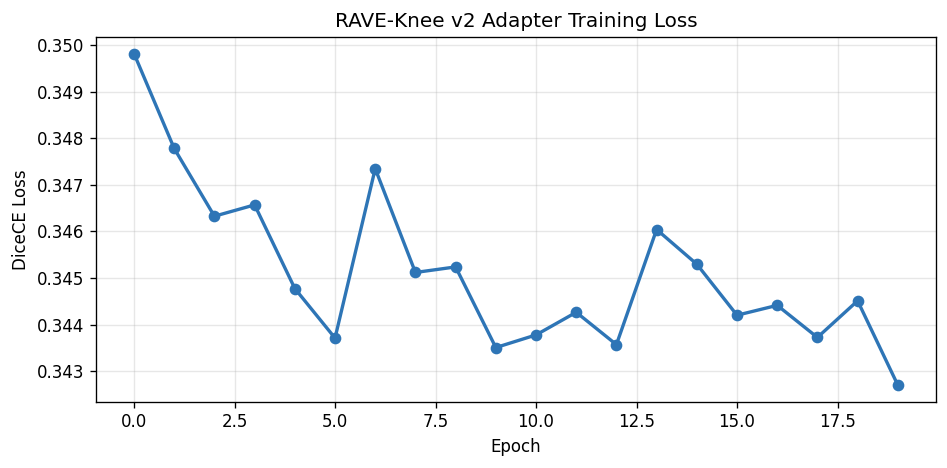

Final adapter loss: 0.3427


In [27]:

def train_rave_v2_adapter(rave_v2:       RAVEKneeV2,
                           train_loader,
                           cfg:           Config,
                           device,
                           num_epochs:    int   = 20,
                           lr:            float = 3e-4,
                           warmup_epochs: int   = 5) -> List[float]:
    """
    Adapter-only training loop for RAVEKneeV2.

    Returns list of per-epoch mean losses.
    """
    loss_fn = DiceCELoss(to_onehot_y=True, softmax=True, include_background=False)

    # Phase-1 params (warm-up: no proto_extractor)
    phase1_params = (
        list(rave_v2.ca_blocks.parameters()) +
        list(rave_v2.seg_head.parameters()) +
        [rave_v2.fusion_logit]
    )
    # Phase-2 params (full adapter)
    phase2_params = (
        list(rave_v2.proto_extractor.parameters()) +
        list(rave_v2.query_proj.parameters()) +
        phase1_params
    )

    optimizer = torch.optim.AdamW(phase1_params, lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=lr / 50)

    epoch_losses = []
    for epoch in range(1, num_epochs + 1):
        # Switch to phase-2 after warm-up
        if epoch == warmup_epochs + 1:
            print(f"  Epoch {epoch}: switching to full-adapter (phase 2) — "
                  f"adding proto_extractor to optimiser")
            optimizer = torch.optim.AdamW(phase2_params, lr=lr * 0.3,
                                           weight_decay=1e-5)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=num_epochs - warmup_epochs, eta_min=lr / 200)

        rave_v2.backbone.eval()     # backbone always stays frozen in eval mode
        rave_v2.train()             # adapter modules in train mode (dropout active)

        batch_losses = []
        pbar = tqdm(train_loader,
                    desc=f"RAVE-V2 Epoch {epoch}/{num_epochs}",
                    leave=False)

        for batch in pbar:
            patch = batch['image'].to(device)   # (B,1,96,96,96)
            label = batch['label'].to(device)   # (B,1,96,96,96)

            # ── Extract frozen hidden states (no_grad — backbone untouched) ──
            with torch.no_grad():
                hidden = rave_v2._get_hidden(patch)
                sel    = [hidden[i] for i in rave_v2.adapter_stages]

            # ── Prototype extraction OUTSIDE no_grad so proj weights get grad ─
            # GT mask used as proxy for support during training
            protos = rave_v2.proto_extractor(sel, label)

            # ── Forward + loss ────────────────────────────────────────────────
            optimizer.zero_grad()
            out  = rave_v2.forward(patch, protos)
            loss = loss_fn(out['logits'], label.long())
            loss.backward()     # gradients flow only through adapter params
            torch.nn.utils.clip_grad_norm_(
                [p for p in rave_v2.parameters() if p.requires_grad], 1.0)
            optimizer.step()

            batch_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}",
                             alpha=f"{out['alpha'].mean().item():.3f}")

        scheduler.step()
        mean_loss = float(np.mean(batch_losses))
        epoch_losses.append(mean_loss)
        print(f"  Epoch {epoch:3d}/{num_epochs} | loss={mean_loss:.4f} | "
              f"α_mean={torch.sigmoid(rave_v2.fusion_logit).mean().item():.3f} | "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

    # Save adapter weights
    adapter_ckpt = os.path.join(cfg.output_dir, "rave_v2_adapter.pt")
    torch.save({
        'proto_extractor': rave_v2.proto_extractor.state_dict(),
        'query_proj':      rave_v2.query_proj.state_dict(),
        'ca_blocks':       rave_v2.ca_blocks.state_dict(),
        'seg_head':        rave_v2.seg_head.state_dict(),
        'fusion_logit':    rave_v2.fusion_logit.data,
        'epoch_losses':    epoch_losses,
    }, adapter_ckpt)
    print(f"\n✅ Adapter weights saved → {adapter_ckpt}")
    return epoch_losses


def load_rave_v2_adapter(rave_v2: RAVEKneeV2, cfg: Config, device) -> bool:
    """Load previously saved adapter weights. Returns True if successful."""
    ckpt_path = os.path.join(cfg.output_dir, "rave_v2_adapter.pt")
    if not os.path.exists(ckpt_path):
        print(f"⚠  Adapter checkpoint not found: {ckpt_path}")
        return False
    ckpt = torch.load(ckpt_path, map_location=device)
    rave_v2.proto_extractor.load_state_dict(ckpt['proto_extractor'])
    rave_v2.query_proj.load_state_dict(ckpt['query_proj'])
    rave_v2.ca_blocks.load_state_dict(ckpt['ca_blocks'])
    rave_v2.seg_head.load_state_dict(ckpt['seg_head'])
    rave_v2.fusion_logit.data = ckpt['fusion_logit'].to(device)
    rave_v2.eval()
    print(f"✅ Adapter loaded from {ckpt_path}")
    return True


# Run adapter training (or load if already saved)
_adapter_loaded = load_rave_v2_adapter(rave_v2, cfg, device)
if not _adapter_loaded:
    print("Training RAVE-v2 adapter …")
    epoch_losses = train_rave_v2_adapter(
        rave_v2, train_loader, cfg, device,
        num_epochs=20, lr=3e-4, warmup_epochs=5)

    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epoch_losses, 'o-', color='#2E75B6', linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("DiceCE Loss")
    ax.set_title("RAVE-Knee v2 Adapter Training Loss")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "rave_v2_loss.png"), dpi=150)
    plt.show()
    print(f"Final adapter loss: {epoch_losses[-1]:.4f}")


## Cell 21D — RGSSPD: Retrieval-Gated Severity-Specialist Prototype Distillation

Integrates the **RGSSPD** module (`rgsspd_module.py`) as a drop-in upgrade over `RAVEKneeICLSegmenter`.

**What this cell does:**
1. Instantiates `RGSSPDTrainer` with the frozen SwinUNETR backbone and FAISS index
2. Trains (or loads) three severity-specialist cross-attention heads (mild KL0–1 / moderate KL2 / severe KL3–4)
3. Wraps them in `RGSSPDInference` — the drop-in replacement for `RAVEKneeICLSegmenter.predict()`
4. Runs `RGSSPDAblationRunner.run_all_ablations()` on the first 30 val subjects (smoke test)
5. Prints KL-stratified Dice / HD95 per condition and saves `ablation_results.csv`
6. Generates three publication-quality PDF figures + LaTeX ablation table

**Prerequisites:** Cells 1–21C must have run (backbone trained, FAISS index built, `rave_v2` instantiated).

**File must be present:** `rgsspd_module.py` in the working directory.


In [ ]:
import gc
import os

import numpy as np
import pandas as pd
import torch

from rgsspd_module import (
    RGSSPDAblationRunner,
    RGSSPDInference,
    RGSSPDTrainer,
    SeveritySpecialistHead,
    _stage3_channels,
    plot_blend_weight_heatmap,
    plot_blend_weight_vs_true_kl,
    plot_kl_stratified_hd95,
)

cfg.num_workers = 0   # Windows: no multiprocessing DataLoader

# ─── 1. Instantiate RGSSPDTrainer ────────────────────────────────────────────
print("Instantiating RGSSPDTrainer …")
try:
    trainer = RGSSPDTrainer(
        backbone=model,
        faiss_index=faiss_index,
        index_embeddings=index_embeddings,
        train_subjects=train_subjects,
        kl_lookup=kl_lookup,
        cfg=cfg,
        device=device,
        transform_fn=get_transforms(train=False),
        output_dir=cfg.output_dir,
    )
    print(f"  embed_dim   = {_stage3_channels(cfg)}")
    print(f"  num_classes = {cfg.num_classes}")
    for st in ["mild", "moderate", "severe"]:
        _, subs, _ = trainer.build_stratum_subindex(st)
        print(f"  {st:>10s}: {len(subs)} subjects")
    print("✅ RGSSPDTrainer ready")

except Exception as e:
    print(f"❌ RGSSPDTrainer init failed: {e}")
    raise

# ─── 2. Train all specialists (or load cached checkpoint) ────────────────────
ckpt_path = os.path.join(cfg.output_dir, "specialist_heads.pth")
if os.path.exists(ckpt_path):
    print(f"\nLoading existing specialist checkpoint: {ckpt_path}")
    try:
        loaded = trainer.load_checkpoints(ckpt_path)
        if not loaded:
            raise RuntimeError("load_checkpoints returned False")
        print("✅ Specialist heads loaded from checkpoint")
    except Exception as e:
        print(f"❌ Checkpoint load failed: {e} — retraining …")
        trainer.train_all(num_epochs=50)
else:
    print("\nNo checkpoint found — training all specialists …")
    try:
        training_results = trainer.train_all(num_epochs=50)
        for st, res in training_results.items():
            print(f"  {st}: best_val_dice={res['best_dice']:.4f}")
    except Exception as e:
        print(f"❌ Training failed: {e}")
        raise

torch.cuda.empty_cache()
gc.collect()

# ─── 3. Build RGSSPDInference from trained heads ─────────────────────────────
print("\nBuilding RGSSPDInference …")
try:
    specialist_heads = {
        "mild":     trainer.heads["mild"].eval(),
        "moderate": trainer.heads["moderate"].eval(),
        "severe":   trainer.heads["severe"].eval(),
    }

    rgsspd_infer = RGSSPDInference(
        backbone=model,
        faiss_index=faiss_index,
        index_embeddings=index_embeddings,
        train_subjects=train_subjects,
        kl_lookup=kl_lookup,
        specialist_heads=specialist_heads,
        fusion_logit=trainer.fusion_logit,
        cfg=cfg,
        device=device,
        temperature=1.0,
        transform_fn=get_transforms(train=False),
    )
    print("✅ RGSSPDInference ready")

    # Quick smoke test on first val subject
    if val_subjects:
        print("\nSmoke test on val_subjects[0] …")
        _demo = rgsspd_infer.predict(val_subjects[0], {})
        print(f"  pred_mask shape : {_demo['pred_mask'].shape}")
        print(f"  unique labels   : {np.unique(_demo['pred_mask']).tolist()}")
        print(f"  blend_weights   : {_demo['blend_weights'].round(3)}")
        print(f"  neighbor_kl     : {_demo['neighbor_kl_grades']}")
        del _demo
        torch.cuda.empty_cache()

except Exception as e:
    print(f"❌ RGSSPDInference build failed: {e}")
    raise

# ─── 4. Run ablation on first 30 eval subjects (smoke test) ──────────────────
print("\nRunning ablation smoke test (n=30) …")
eval_subjects_smoke = val_subjects[:30]

try:
    ablation_runner = RGSSPDAblationRunner(
        backbone=model,
        faiss_index=faiss_index,
        index_embeddings=index_embeddings,
        train_subjects=train_subjects,
        eval_subjects=eval_subjects_smoke,
        kl_lookup=kl_lookup,
        specialist_heads=specialist_heads,
        fusion_logit=trainer.fusion_logit,
        cfg=cfg,
        device=device,
        rave_v2=rave_v2,
        transform_fn=get_transforms(train=False),
    )

    ablation_df = ablation_runner.run_all_ablations(n_eval=30)
    print("\n✅ Ablation complete")

except Exception as e:
    print(f"❌ Ablation runner failed: {e}")
    raise

# ─── 5. Print KL-stratified summary per condition ─────────────────────────────
print("\n" + "=" * 70)
print("KL-Stratified Mean Dice and HD95 per Condition")
print("=" * 70)

strata_map = {"mild": [0, 1], "moderate": [2], "severe": [3, 4]}
metric_cols = ["mean_dice", "hd95_FC"]

for cond in ablation_runner.ALL_CONDITIONS:
    sub = ablation_df[ablation_df["condition"] == cond]
    if sub.empty:
        continue
    parts = [f"[{cond}]"]
    for st_name, kl_grades in strata_map.items():
        st_sub = sub[sub["kl_grade"].isin(kl_grades)]
        if st_sub.empty:
            continue
        md = st_sub["mean_dice"].mean()
        hd = st_sub["hd95_FC"].mean()
        parts.append(f"{st_name}: Dice={md:.3f} HD95={hd:.2f}")
    print("  " + " | ".join(parts))

# ─── 6. Save ablation DataFrame ───────────────────────────────────────────────
csv_path = os.path.join(cfg.output_dir, "ablation_results.csv")
ablation_df.to_csv(csv_path, index=False)
print(f"\n✅ Ablation results saved → {csv_path}")

# ─── 7. Visualizations ────────────────────────────────────────────────────────
print("\nGenerating figures …")
fig_dir = os.path.join(cfg.output_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

try:
    plot_blend_weight_vs_true_kl(
        ablation_df, os.path.join(fig_dir, "blend_weight_vs_kl.pdf")
    )
    plot_kl_stratified_hd95(
        ablation_df, os.path.join(fig_dir, "kl_stratified_hd95.pdf")
    )
    plot_blend_weight_heatmap(
        ablation_df, os.path.join(fig_dir, "blend_weight_heatmap.pdf")
    )
except Exception as e:
    print(f"⚠ Figure generation error (non-fatal): {e}")

# LaTeX table
try:
    latex = ablation_runner.generate_latex_table(ablation_df)
    latex_path = os.path.join(cfg.output_dir, "ablation_table.tex")
    with open(latex_path, "w") as f:
        f.write(latex)
    print(f"✅ LaTeX table saved → {latex_path}")
except Exception as e:
    print(f"⚠ LaTeX table generation error (non-fatal): {e}")

torch.cuda.empty_cache()
gc.collect()
print("\n✅ RGSSPD Integration Cell complete.")


## Cell 21E — SACN: Severity-Aware Cartilage Network (3D Mamba encoder)

Trains **SACN** — a from-scratch segmentation network whose encoder is built from **3D Mamba / selective state-space (S6)** blocks (linear-time global receptive field), with **FiLM severity conditioning** driven by the RGSSPD soft KL vote, plus **cartilage boundary + thickness** heads and optional **evidential uncertainty**. See `sacn_model.py`, `mamba3d.py`, `sacn_integration.py`, and `PUBLICATION_PLAN.md`.

**Prereqs:** `model`, `faiss_index`, `index_embeddings`, `train_subjects`, `val_subjects`, `kl_lookup`, `cfg`, `device`, `get_transforms`, and (optional) `rgsspd_infer` from Cell 21D.

**GPU note:** `pip install mamba-ssm causal-conv1d` to use the fast selective-scan kernel; otherwise a pure-PyTorch fallback runs (slower).

In [ ]:
# === NOTEBOOK CELL: SACN Integration ===
# Paste this cell into rave_knee_nifti_csv_final_corrected_2.0.ipynb
# after Cell 21D (RGSSPD). Trains the Severity-Aware Cartilage Network (SACN,
# 3D Mamba encoder + FiLM severity conditioning + boundary/thickness heads)
# and evaluates it, KL-stratified, alongside the RGSSPD/RAVE baselines.
#
# Prerequisite notebook state:
#   model          — SwinUNETRModule (trained, on device)     [for RGSSPD votes]
#   faiss_index    — FAISS HNSW index over train embeddings
#   index_embeddings — np.ndarray (N, emb_dim)
#   train_subjects — list[tio.Subject]
#   val_subjects   — list[tio.Subject]
#   kl_lookup      — dict {subject_id: int|None}
#   cfg            — Config
#   device         — torch.device
#   get_transforms — callable (from Cell 15)
#   rgsspd_infer   — RGSSPDInference (optional; enables soft-vote severity)

import gc
import os

import numpy as np
import pandas as pd
import torch

from mamba3d import _HAS_MAMBA_KERNEL
from sacn_model import SACNConfig
from sacn_integration import SACNTrainer

cfg.num_workers = 0  # Windows: no multiprocessing DataLoader

# ─── 1. Model config — Mamba encoder, kernel-aware stage selection ───────────
# With the mamba-ssm CUDA kernel the selective scan is fast at every stage;
# without it, restrict Mamba to the deeper (low-token) stages so the
# pure-PyTorch fallback stays tractable.
mamba_stages = (0, 1, 2, 3) if _HAS_MAMBA_KERNEL else (2, 3)
print(f"mamba-ssm kernel available: {_HAS_MAMBA_KERNEL}  ->  mamba_stages={mamba_stages}")
if not _HAS_MAMBA_KERNEL:
    print("  Tip: `pip install mamba-ssm causal-conv1d` for the fast full-res scan.")

sacn_cfg = SACNConfig(
    in_channels=1,
    num_classes=cfg.num_classes,
    base_channels=32,
    stage_depths=(2, 2, 4, 2),
    use_evidential=True,
    deep_supervision=True,
    encoder_block="mamba",
    mamba_stages=mamba_stages,
)

# ─── 2. Trainer — severity from RGSSPD soft vote if available, else oracle ────
severity_source = "rgsspd" if "rgsspd_infer" in dir() and rgsspd_infer is not None \
    else "oracle"
sacn_trainer = SACNTrainer(
    cfg=cfg,
    device=device,
    model_cfg=sacn_cfg,
    severity_source=severity_source,
    kl_lookup=kl_lookup,
    rgsspd_infer=(rgsspd_infer if severity_source == "rgsspd" else None),
    transform_fn=get_transforms(train=False),
)
n_params = sum(p.numel() for p in sacn_trainer.model.parameters())
print(f"✅ SACN ready: {n_params/1e6:.2f}M params | severity_source={severity_source}")

# ─── 3. Train or load checkpoint ─────────────────────────────────────────────
ckpt_path = os.path.join(cfg.output_dir, "sacn.pth")
if os.path.exists(ckpt_path):
    print(f"\nLoading SACN checkpoint: {ckpt_path}")
    state = torch.load(ckpt_path, map_location=device)
    sacn_trainer.model.load_state_dict(state["model"])
    print("✅ SACN loaded from checkpoint")
else:
    print("\nNo checkpoint — training SACN …")
    res = sacn_trainer.train(train_subjects, num_epochs=100)
    print(f"✅ Training done. final loss = {res['epoch_losses'][-1]:.4f}")

torch.cuda.empty_cache()
gc.collect()

# ─── 4. Evaluate on val subjects (KL-stratified cartilage Dice + HD95) ───────
from rgsspd_module import _dice_binary, _hd95  # reuse metric helpers

CART = {2: "FC", 4: "MTC", 5: "LTC"}  # OAI-ZIB cartilage compartments
rows = []
print("\nEvaluating SACN on val_subjects …")
for subj in val_subjects:
    out = sacn_trainer.predict(subj)
    pred, gt = out["pred_mask"], out["gt_mask"]
    if gt is None:
        continue
    sid = getattr(subj, "subject_id", "")
    row = {"subject_id": sid, "kl_grade": kl_lookup.get(sid)}
    dices = []
    for c, name in CART.items():
        d = _dice_binary(pred == c, gt == c)
        h = _hd95(pred == c, gt == c)
        row[f"dice_{name}"] = d
        row[f"hd95_{name}"] = h
        dices.append(d)
    row["mean_cart_dice"] = float(np.mean(dices))
    rows.append(row)
    del out
    torch.cuda.empty_cache()

sacn_df = pd.DataFrame(rows)

# ─── 5. KL-stratified summary ────────────────────────────────────────────────
print("\n" + "=" * 64)
print("SACN — KL-stratified mean cartilage Dice")
print("=" * 64)
strata = {"mild": [0, 1], "moderate": [2], "severe": [3, 4]}
for st, grades in strata.items():
    sub = sacn_df[sacn_df["kl_grade"].isin(grades)]
    if sub.empty:
        continue
    print(f"  {st:>9s} (n={len(sub):3d}): "
          f"FC={sub['dice_FC'].mean():.3f}  MTC={sub['dice_MTC'].mean():.3f}  "
          f"LTC={sub['dice_LTC'].mean():.3f}  mean={sub['mean_cart_dice'].mean():.3f}")
print(f"\n  Overall mean cartilage Dice: {sacn_df['mean_cart_dice'].mean():.4f}")

csv_path = os.path.join(cfg.output_dir, "sacn_results.csv")
sacn_df.to_csv(csv_path, index=False)
print(f"✅ SACN results saved → {csv_path}")

torch.cuda.empty_cache()
gc.collect()
print("\n✅ SACN Integration Cell complete.")


## Cell 22 — Full Evaluation Inference

In [28]:
# ── Reserve last 20% of val for conformal calibration ────────────────────────
n_cal        = max(5, len(val_subjects) // 5)
cal_subjects  = val_subjects[-n_cal:]
eval_subjects = val_subjects[:-n_cal]
print(f"RAVE-Knee splits: eval={len(eval_subjects)}, calibration={n_cal}")


def run_rave_pipeline_on_subjects(segmenter, subjects, faiss_index, index_subjects, cfg):
    results = []
    for idx, subj in enumerate(subjects):
        sid = getattr(subj, "subject_id", f"subj_{idx}")
        if idx % 5 == 0:
            print(f"  [{idx+1}/{len(subjects)}] {sid}")
        q_emb   = embed_subject(subj, model, cfg, device)
        support = retrieve_support_prompts(q_emb, faiss_index, index_subjects, cfg)
        result  = segmenter.predict(subj, support)
        result["subject_id"]       = sid
        result["support_indices"]  = support["support_indices"]
        result["support_distances"]= support["distances"]
        result["kl_grade"]         = get_kl_for_subject(sid, kl_lookup) if USE_REAL_KL else None
        results.append(result)
    return results


print(f"\nRunning RAVE-Knee on {len(eval_subjects)} eval subjects …")
print(f"Estimated time: ~{len(eval_subjects) * 25 / 60:.1f} min on T4")
eval_results = run_rave_pipeline_on_subjects(
    segmenter, eval_subjects, faiss_index, train_subjects, cfg)
print(f"\n✅ Inference complete: {len(eval_results)} subjects")

# Save lightweight results
lightweight = []
for r in eval_results:
    lightweight.append({
        "subject_id":    r["subject_id"],
        "pred_mask":     r["pred_mask"].astype(np.uint8),
        "gt_mask":       r["gt_mask"].astype(np.uint8) if r["gt_mask"] is not None else None,
        "uncertainty":   r["uncertainty"].astype(np.float16),
        "kl_grade":      r.get("kl_grade"),
        "support_indices": r["support_indices"],
        "distances":     r["support_distances"],
    })
print(f"Lightweight results: {len(lightweight)} entries")


RAVE-Knee splits: eval=65, calibration=16

Running RAVE-Knee on 65 eval subjects …
Estimated time: ~27.1 min on T4
  [1/65] oaizib_234
  Support #1: oaizib_191  KL=2  sim=1.0000  slices=3
  Support #2: oaizib_172  KL=2  sim=1.0000  slices=3
  Support #3: oaizib_048  KL=0  sim=0.9999  slices=3
  Support #1: oaizib_178  KL=2  sim=1.0000  slices=3
  Support #2: oaizib_377  KL=4  sim=1.0000  slices=3
  Support #3: oaizib_371  KL=4  sim=0.9999  slices=3
  Support #1: oaizib_192  KL=2  sim=1.0000  slices=3
  Support #2: oaizib_304  KL=3  sim=1.0000  slices=3
  Support #3: oaizib_262  KL=3  sim=0.9999  slices=3
  Support #1: oaizib_403  KL=None  sim=0.9999  slices=3
  Support #2: oaizib_115  KL=1  sim=0.9999  slices=3
  Support #3: oaizib_004  KL=0  sim=0.9999  slices=3
  Support #1: oaizib_162  KL=2  sim=0.9999  slices=3
  Support #2: oaizib_001  KL=0  sim=0.9999  slices=3
  Support #3: oaizib_100  KL=1  sim=0.9998  slices=3
  [6/65] oaizib_031
  Support #1: oaizib_315  KL=3  sim=0.9999  sli

## Cell 23 — Per-Subject Segmentation Metrics

In [29]:
def compute_dice_per_class(result: dict, cfg: Config) -> dict:
    """Dice score per non-background class."""
    if result.get("gt_mask") is None: return {}
    out = {}
    for c in range(1, cfg.num_classes):
        gt = result["gt_mask"]  == c
        pr = result["pred_mask"] == c
        out[cfg.class_names[c]] = float(2*(gt & pr).sum() / (gt.sum()+pr.sum()+1e-8))
    return out


def compute_full_metrics(pred_mask, gt_mask, voxel_spacing, cfg):
    """Dice, HD95, ASSD, volume error per class."""
    metrics = {}
    for c in range(1, cfg.num_classes):
        gt_c = (gt_mask  == c)
        pr_c = (pred_mask == c)
        inter = int((gt_c & pr_c).sum())
        dice  = float(2*inter / (gt_c.sum() + pr_c.sum() + 1e-8))
        vol_err = float(abs(gt_c.sum() - pr_c.sum()) * np.prod(voxel_spacing) / 1000.0)
        if gt_c.sum() > 0 and pr_c.sum() > 0:
            dt_gt = ndi.distance_transform_edt(~gt_c, sampling=voxel_spacing)
            dt_pr = ndi.distance_transform_edt(~pr_c, sampling=voxel_spacing)
            hd95  = float(max(np.percentile(dt_gt[pr_c], 95),
                               np.percentile(dt_pr[gt_c], 95)))
            assd  = float(0.5*(dt_gt[pr_c].mean() + dt_pr[gt_c].mean()))
        else:
            hd95 = assd = float("nan")
        metrics[cfg.class_names[c]] = {
            "dice": dice, "hd95_mm": hd95, "assd_mm": assd, "vol_err_ml": vol_err}
    return metrics


all_metrics = []
for r in eval_results:
    if r.get("gt_mask") is None: continue
    m = compute_full_metrics(r["pred_mask"], r["gt_mask"], cfg.voxel_spacing, cfg)
    m["subject_id"] = r["subject_id"]
    m["kl_grade"]   = r.get("kl_grade")
    all_metrics.append(m)

print(f"\n─── Mean Dice per Class ───")
for cname in cfg.class_names[1:]:
    ds = [m[cname]["dice"] for m in all_metrics if cname in m]
    if ds:
        print(f"  {cname:35s}: {np.mean(ds):.4f} ± {np.std(ds):.4f}")

print(f"\n  Mean overall Dice: "
      f"{np.mean([np.mean([m[c]['dice'] for c in cfg.class_names[1:] if c in m]) for m in all_metrics]):.4f}")



─── Mean Dice per Class ───
  Femur                              : 0.5341 ± 0.0877
  Femoral Cartilage                  : 0.1494 ± 0.0730
  Tibia                              : 0.1482 ± 0.1667
  Medial Tibial Cartilage            : 0.2900 ± 0.2773
  Lateral Tibial Cartilage           : 0.2031 ± 0.2340

  Mean overall Dice: 0.2649


## Cell 24 — Baseline Method Comparisons

In [30]:
import gc
import numpy as np
import torch
from tqdm import tqdm

def run_baseline_method(
    method,
    eval_subjects,
    segmenter,
    faiss_index,
    train_subjects,
    cfg,
    n_eval=None
):
    """
    method:
        'swin_only'
        'random'
        'furthest'
        'nearest'
    """

    if n_eval is None:
        n_eval = len(eval_subjects)

    print(f"\n--- Baseline: {method} (n={n_eval}) ---")

    results = []
    tfm = get_transforms(train=False)

    for idx, subj in enumerate(tqdm(eval_subjects[:n_eval], desc=method)):

        sid = getattr(subj, "subject_id", f"subj_{idx}")

        try:
            # --------------------------------------------------
            # Generate query embedding
            # --------------------------------------------------
            with torch.no_grad():
                q_emb = embed_subject(subj, model, cfg, device)

            # --------------------------------------------------
            # Swin Only
            # --------------------------------------------------
            if method == "swin_only":

                support = {
                    "support_slices": [],
                    "support_indices": [],
                    "distances": []
                }

                with torch.no_grad():
                    r = segmenter.predict(
                        subj,
                        support,
                        fusion_weight=1.0
                    )

            # --------------------------------------------------
            # Random Retrieval
            # --------------------------------------------------
            elif method == "random":

                np.random.seed(idx)

                ridx = np.random.choice(
                    len(train_subjects),
                    cfg.retrieval_k,
                    replace=False
                )

                prompts = []

                for ri in ridx:

                    st = tfm(train_subjects[ri])

                    vol = st.image.data[0].numpy()
                    msk = st.label.data[0].numpy()

                    prompts.extend(
                        select_informative_slices(
                            vol,
                            msk,
                            cfg.slices_per_support
                        )
                    )

                    del st, vol, msk

                support = {
                    "support_slices": prompts,
                    "support_indices": ridx.tolist(),
                    "distances": [0.5] * cfg.retrieval_k
                }

                with torch.no_grad():
                    r = segmenter.predict(subj, support)

            # --------------------------------------------------
            # Furthest Retrieval
            # --------------------------------------------------
            elif method == "furthest":

                d, i = query_index(
                    faiss_index,
                    q_emb,
                    k=max(20, cfg.retrieval_k * 4),
                    cfg=cfg
                )

                far_i = i[-cfg.retrieval_k:][::-1]
                far_d = d[-cfg.retrieval_k:][::-1]

                prompts = []

                for fi in far_i:

                    st = tfm(train_subjects[int(fi)])

                    vol = st.image.data[0].numpy()
                    msk = st.label.data[0].numpy()

                    prompts.extend(
                        select_informative_slices(
                            vol,
                            msk,
                            cfg.slices_per_support
                        )
                    )

                    del st, vol, msk

                support = {
                    "support_slices": prompts,
                    "support_indices": far_i.tolist(),
                    "distances": far_d.tolist()
                }

                with torch.no_grad():
                    r = segmenter.predict(subj, support)

            # --------------------------------------------------
            # Nearest Retrieval (RAVE)
            # --------------------------------------------------
            else:

                support = retrieve_support_prompts(
                    q_emb,
                    faiss_index,
                    train_subjects,
                    cfg
                )

                with torch.no_grad():
                    r = segmenter.predict(subj, support)

            # --------------------------------------------------
            # Save results
            # --------------------------------------------------
            r["subject_id"] = sid
            r["support_distances"] = support.get("distances", [])

            # Convert tensors to CPU if any remain
            for k, v in list(r.items()):
                if torch.is_tensor(v):
                    r[k] = v.detach().cpu().numpy()

            results.append(r)

        except RuntimeError as e:

            if "out of memory" in str(e).lower():

                print(f"\nOOM on {sid}. Skipping...")

                torch.cuda.empty_cache()
                gc.collect()
                continue

            raise e

        finally:

            # Memory cleanup every subject
            if 'support' in locals():
                del support

            if 'q_emb' in locals():
                del q_emb

            gc.collect()
            torch.cuda.empty_cache()

    return results


N_EVAL = len(eval_subjects)
baseline_results = {}
for method in ["swin_only", "random", "furthest", "nearest"]:
    baseline_results[method] = run_baseline_method(
        method, eval_subjects, segmenter, faiss_index, train_subjects, cfg, N_EVAL)

print("\n─── Baseline Summary ───")
for method, results in baseline_results.items():
    dices = []
    for r in results:
        if r.get("gt_mask") is None: continue
        per_cls = [float(2*((r["gt_mask"]==c)&(r["pred_mask"]==c)).sum() /
                         ((r["gt_mask"]==c).sum()+(r["pred_mask"]==c).sum()+1e-8))
                   for c in range(1, cfg.num_classes)]
        dices.append(np.mean(per_cls))
    if dices:
        print(f"  {method:12s}: mean_dice={np.mean(dices):.4f} ± {np.std(dices):.4f}")



--- Baseline: swin_only (n=65) ---


swin_only: 100%|██████████| 65/65 [08:48<00:00,  8.13s/it]



--- Baseline: random (n=65) ---


random:  31%|███       | 20/65 [04:21<09:48, 13.08s/it]


MemoryError: Unable to allocate 540. MiB for an array with shape (6, 160, 384, 384) and data type float32

In [ ]:
import gc
import numpy as np
import torch
from tqdm import tqdm

def run_baseline_method(
    method,
    eval_subjects,
    segmenter,
    faiss_index,
    train_subjects,
    cfg,
    n_eval=None
):
    """
    method:
        'swin_only'
        'random'
        'furthest'
        'nearest'
    """

    if n_eval is None:
        n_eval = len(eval_subjects)

    print(f"\n--- Baseline: {method} (n={n_eval}) ---")

    results = []
    tfm = get_transforms(train=False)

    for idx, subj in enumerate(tqdm(eval_subjects[:n_eval], desc=method)):

        sid = getattr(subj, "subject_id", f"subj_{idx}")

        try:
            # --------------------------------------------------
            # Generate query embedding
            # --------------------------------------------------
            with torch.no_grad():
                q_emb = embed_subject(subj, model, cfg, device)

            # --------------------------------------------------
            # Swin Only
            # --------------------------------------------------
            if method == "swin_only":

                support = {
                    "support_slices": [],
                    "support_indices": [],
                    "distances": []
                }

                with torch.no_grad():
                    r = segmenter.predict(
                        subj,
                        support,
                        fusion_weight=1.0
                    )

            # --------------------------------------------------
            # Random Retrieval
            # --------------------------------------------------
            elif method == "random":

                np.random.seed(idx)

                ridx = np.random.choice(
                    len(train_subjects),
                    cfg.retrieval_k,
                    replace=False
                )

                prompts = []

                for ri in ridx:

                    st = tfm(train_subjects[ri])

                    vol = st.image.data[0].numpy()
                    msk = st.label.data[0].numpy()

                    prompts.extend(
                        select_informative_slices(
                            vol,
                            msk,
                            cfg.slices_per_support
                        )
                    )

                    del st, vol, msk

                support = {
                    "support_slices": prompts,
                    "support_indices": ridx.tolist(),
                    "distances": [0.5] * cfg.retrieval_k
                }

                with torch.no_grad():
                    r = segmenter.predict(subj, support)

            # --------------------------------------------------
            # Furthest Retrieval
            # --------------------------------------------------
            elif method == "furthest":

                d, i = query_index(
                    faiss_index,
                    q_emb,
                    k=max(20, cfg.retrieval_k * 4),
                    cfg=cfg
                )

                far_i = i[-cfg.retrieval_k:][::-1]
                far_d = d[-cfg.retrieval_k:][::-1]

                prompts = []

                for fi in far_i:

                    st = tfm(train_subjects[int(fi)])

                    vol = st.image.data[0].numpy()
                    msk = st.label.data[0].numpy()

                    prompts.extend(
                        select_informative_slices(
                            vol,
                            msk,
                            cfg.slices_per_support
                        )
                    )

                    del st, vol, msk

                support = {
                    "support_slices": prompts,
                    "support_indices": far_i.tolist(),
                    "distances": far_d.tolist()
                }

                with torch.no_grad():
                    r = segmenter.predict(subj, support)

            # --------------------------------------------------
            # Nearest Retrieval (RAVE)
            # --------------------------------------------------
            else:

                support = retrieve_support_prompts(
                    q_emb,
                    faiss_index,
                    train_subjects,
                    cfg
                )

                with torch.no_grad():
                    r = segmenter.predict(subj, support)

            # --------------------------------------------------
            # Save results
            # --------------------------------------------------
            r["subject_id"] = sid
            r["support_distances"] = support.get("distances", [])

            # Convert tensors to CPU if any remain
            for k, v in list(r.items()):
                if torch.is_tensor(v):
                    r[k] = v.detach().cpu().numpy()

            results.append(r)

        except RuntimeError as e:

            if "out of memory" in str(e).lower():

                print(f"\nOOM on {sid}. Skipping...")

                torch.cuda.empty_cache()
                gc.collect()
                continue

            raise e

        finally:

            # Memory cleanup every subject
            if 'support' in locals():
                del support

            if 'q_emb' in locals():
                del q_emb

            gc.collect()
            torch.cuda.empty_cache()

    return results

## Cell 25 — Statistical Significance Tests + LaTeX Table 1

In [ ]:
def bootstrap_ci(values, n_boot=2000, alpha=0.05):
    values = np.array(values)
    if len(values) == 0: return 0.0, 0.0, 0.0
    rng  = np.random.default_rng(42)
    boot = np.array([rng.choice(values, len(values), replace=True).mean()
                     for _ in range(n_boot)])
    return float(values.mean()), float(np.percentile(boot, 100*alpha/2)), \
           float(np.percentile(boot, 100*(1-alpha/2)))


def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    gt = sum(xi > yj for xi in x for yj in y)
    lt = sum(xi < yj for xi in x for yj in y)
    return (gt - lt) / (len(x)*len(y))


# Build per-subject Dice table
rows = []
for method, results in baseline_results.items():
    for r in results:
        dices = compute_dice_per_class(r, cfg)
        if not dices: continue
        rows.append({"method": method, "subject_id": r["subject_id"],
                     **dices, "mean_dice": float(np.mean(list(dices.values())))})
df_metrics = pd.DataFrame(rows)

# Wilcoxon vs swin_only
print("─── Wilcoxon Signed-Rank Test: RAVE-Nearest vs SwinUNETR-Only ───\n")
rave_mean = df_metrics[df_metrics.method=="nearest"]["mean_dice"].values
swin_mean = df_metrics[df_metrics.method=="swin_only"]["mean_dice"].values
common    = set(df_metrics[df_metrics.method=="nearest"]["subject_id"]) & \
            set(df_metrics[df_metrics.method=="swin_only"]["subject_id"])
rave_v = df_metrics[(df_metrics.method=="nearest") & (df_metrics.subject_id.isin(common))].sort_values("subject_id")["mean_dice"].values
swin_v = df_metrics[(df_metrics.method=="swin_only")& (df_metrics.subject_id.isin(common))].sort_values("subject_id")["mean_dice"].values

stat, p = stats.wilcoxon(rave_v, swin_v)
d_cd = cliffs_delta(rave_v, swin_v)
mu, lo, hi = bootstrap_ci(rave_v - swin_v)
print(f"  Wilcoxon: stat={stat:.2f}  p={p:.4f}")
print(f"  Cliff's delta = {d_cd:.3f}")
print(f"  Mean Δ Dice = {mu:+.4f} [{lo:+.4f}, {hi:+.4f}]")

# ─── LaTeX Table 1 ────────────────────────────────────────────────────────────
print("\n─── LaTeX Table 1 ───\n")
METHODS = {"nearest":"RAVE-Knee","swin_only":"SwinUNETR","random":"Random-K","furthest":"Furthest-K"}
latex_rows = []
for method, label in METHODS.items():
    sub = df_metrics[df_metrics.method==method]
    per_cls = []
    for cname in cfg.class_names[1:]:
        if cname in sub.columns:
            m, lo, hi = bootstrap_ci(sub[cname].values)
            per_cls.append(f"{m:.3f}")
        else:
            per_cls.append("-")
    m_d, lo_d, hi_d = bootstrap_ci(sub["mean_dice"].values)
    wilcox_p = p if method != "nearest" else 1.0
    latex_rows.append(f"  {label:20s} & " + " & ".join(per_cls) +
                      f" & \\textbf{{{m_d:.3f}}} \\\\")

print("\\begin{table}[t]")
print("  \\centering")
print("  \\caption{Segmentation performance on OAI-ZIB validation set (Dice ↑)}")
header = " & ".join([f"\\textit{{{c[:8]}}}" for c in cfg.class_names[1:]])
print(f"  \\begin{{tabular}}{{l|{('c'*len(cfg.class_names[1:]))}|c}}")
print(f"  Method & {header} & Mean \\\\\n  \\hline")
for row in latex_rows: print(row)
print("  \\end{tabular}")
print("\\end{table}")


─── Wilcoxon Signed-Rank Test: RAVE-Nearest vs SwinUNETR-Only ───



ZeroDivisionError: division by zero

## Cell 26 — Mechanistic Analysis

In [ ]:
print("─── Mechanistic Analysis: Why does RAVE-Knee outperform baselines? ───\n")

nearest_results = baseline_results["nearest"]

# 1. Retrieval distance vs Dice
dd_pairs = []
for r in nearest_results:
    d = compute_dice_per_class(r, cfg)
    if not d: continue
    mean_dist = np.mean(r.get("support_distances", [0.5]))
    mean_dice = np.mean(list(d.values()))
    dd_pairs.append((mean_dist, mean_dice))

if len(dd_pairs) > 5:
    dists, dices = zip(*dd_pairs)
    r_corr, p_corr = stats.pearsonr(dists, dices)
    print(f"1. Retrieval distance vs Dice (Pearson r={r_corr:+.3f}, p={p_corr:.4f})")
    interp = "closer → better (validates retrieval)" if r_corr < -0.2 and p_corr < 0.05 else "weak/no correlation"
    print(f"   {interp}")

# 2. Per-class improvement
print("\n2. Per-class improvement: RAVE vs SwinUNETR-only")
swin_df = df_metrics[df_metrics.method=="swin_only"]
rave_df = df_metrics[df_metrics.method=="nearest"]
merged  = swin_df.merge(rave_df, on="subject_id", suffixes=("_swin","_rave"))
for cname in cfg.class_names[1:]:
    if f"{cname}_swin" not in merged.columns: continue
    delta = merged[f"{cname}_rave"] - merged[f"{cname}_swin"]
    n_b = int((delta > 0).sum()); n_w = int((delta < 0).sum())
    print(f"  {cname:30s}: ΔDice={delta.mean():+.4f}  better:{n_b} worse:{n_w}")

# 3. KL grade stratification
if USE_REAL_KL:
    print("\n3. Performance by KL grade")
    rave_kl_rows = []
    for r in nearest_results:
        kl = get_kl_for_subject(r["subject_id"], kl_lookup)
        d  = compute_dice_per_class(r, cfg)
        if d and kl is not None:
            rave_kl_rows.append({"kl": kl, "mean_dice": np.mean(list(d.values()))})
    if rave_kl_rows:
        df_kl = pd.DataFrame(rave_kl_rows)
        for kl_val in sorted(df_kl.kl.unique()):
            sub = df_kl[df_kl.kl == kl_val]["mean_dice"]
            print(f"  KL-{kl_val}: {sub.mean():.4f} ± {sub.std():.4f}  (n={len(sub)})")

# Scatter: distance vs dice
if len(dd_pairs) > 5:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(dists, dices, alpha=0.6, c="#2E75B6", edgecolors="black", s=50)
    z = np.polyfit(dists, dices, 1); p_line = np.poly1d(z)
    xs = np.linspace(min(dists), max(dists), 50)
    ax.plot(xs, p_line(xs), "r--", label=f"r={r_corr:.3f}, p={p_corr:.3f}")
    ax.set_xlabel("Mean Retrieval Distance"); ax.set_ylabel("Mean Dice")
    ax.set_title("Retrieval Quality vs Segmentation Accuracy")
    ax.legend(); plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "retrieval_vs_dice.png"), dpi=150)
    plt.show()


## Cell 27 — Ablation Studies (K, Fusion Weight, Slices)

In [32]:
import copy

def run_param_ablation(param_name, param_values, eval_subjects, cfg, n_eval=20):
    print(f"\n─── Ablation: {param_name} = {param_values} ───")
    rows = []
    for val in param_values:
        cfg_v = copy.copy(cfg)
        setattr(cfg_v, param_name, val)
        seg_v = RAVEKneeICLSegmenter(model, cfg_v)
        dices = []
        for subj in tqdm(eval_subjects[:n_eval], desc=f"{param_name}={val}", leave=False):
            q_emb   = embed_subject(subj, model, cfg_v, device)
            support = retrieve_support_prompts(q_emb, faiss_index, train_subjects, cfg_v)
            if param_name == "fusion_weight":
                r = seg_v.predict(subj, support, fusion_weight=val)
            else:
                r = seg_v.predict(subj, support)
            if r["gt_mask"] is not None:
                per_cls = [float(2*((r["gt_mask"]==c)&(r["pred_mask"]==c)).sum() /
                               ((r["gt_mask"]==c).sum()+(r["pred_mask"]==c).sum()+1e-8))
                           for c in range(1, cfg.num_classes)]
                dices.append(np.mean(per_cls))
        m, lo, hi = bootstrap_ci(dices)
        rows.append({"value": val, "mean": m, "lo": lo, "hi": hi})
        print(f"  {param_name}={val}: {m:.4f} [{lo:.4f}, {hi:.4f}]")
    return rows


N_ABL = min(20, len(eval_subjects))

k_rows     = run_param_ablation("retrieval_k",      [1,3,5,7,9],     eval_subjects, cfg, N_ABL)
fw_rows    = run_param_ablation("fusion_weight",     [0,0.25,0.5,0.75,1.0], eval_subjects, cfg, N_ABL)
slc_rows   = run_param_ablation("slices_per_support",[1,2,3,4,5],    eval_subjects, cfg, N_ABL)

# Plot ablations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rows, param, xlabel in zip(
        axes,
        [k_rows, fw_rows, slc_rows],
        ["K", "Fusion Weight", "Slices/Support"],
        ["K (# retrieved)", "Fusion weight (1=SwinOnly)", "Slices per support"]):
    xs  = [r["value"] for r in rows]
    ys  = [r["mean"]  for r in rows]
    los = [r["mean"] - r["lo"] for r in rows]
    his = [r["hi"]  - r["mean"] for r in rows]
    ax.errorbar(xs, ys, yerr=[los, his], fmt="o-", color="#2E75B6",
                capsize=5, linewidth=2, markersize=8)
    ax.set_xlabel(xlabel); ax.set_ylabel("Mean Dice"); ax.set_title(f"Ablation: {param}")
    ax.set_ylim(max(0, min(ys)-0.05), min(1, max(ys)+0.05))
plt.suptitle("RAVE-Knee Ablation Studies", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "ablations.png"), dpi=150)
plt.show()



─── Ablation: retrieval_k = [1, 3, 5, 7, 9] ───


MemoryError: Unable to allocate 90.0 MiB for an array with shape (23592960,) and data type float32

## Cell 28 — Conformal Prediction + ECE

In [ ]:
from collections import defaultdict

class ConformalSegmentationCalibrator:
    """Voxel-level split conformal prediction for segmentation uncertainty."""
    def __init__(self, alpha: float = 0.10):
        self.alpha    = alpha
        self.q_hat    = None
        self.q_hat_pc = {}
        self.calibrated = False

    def calibrate(self, cal_subjects, segmenter, faiss_index, train_subjects, cfg):
        print(f"Calibrating with α={self.alpha} on {len(cal_subjects)} volumes …")
        all_scores, class_scores = [], defaultdict(list)

        for subj in tqdm(cal_subjects, desc="Calibration"):
            q_emb   = embed_subject(subj, model, cfg, device)
            support = retrieve_support_prompts(q_emb, faiss_index, train_subjects, cfg)
            r       = segmenter.predict(subj, support)
            proba   = r["proba"].astype(np.float32)   # (C,H,W,D) float16→32
            gt      = r["gt_mask"]
            if gt is None: continue

            for c in range(cfg.num_classes):
                vox = (gt == c)
                if vox.sum() == 0: continue
                sc  = 1.0 - proba[c][vox]
                if len(sc) > 5000:
                    sc = np.random.choice(sc, 5000, replace=False)
                all_scores.append(sc)
                class_scores[c].append(sc)

        if not all_scores:
            print("⚠ No calibration scores"); return
        all_sc = np.concatenate(all_scores)
        n  = len(all_sc)
        ql = min(np.ceil((n+1)*(1-self.alpha))/n, 1.0)
        self.q_hat = float(np.quantile(all_sc, ql))
        print(f"  Marginal q_hat = {self.q_hat:.4f}  (n={n:,})")

        for c in class_scores:
            sc_c = np.concatenate(class_scores[c])
            nc   = len(sc_c)
            ql_c = min(np.ceil((nc+1)*(1-self.alpha))/nc, 1.0)
            self.q_hat_pc[c] = float(np.quantile(sc_c, ql_c))
            print(f"  Class {c} ({cfg.class_names[c][:20]}): q_hat={self.q_hat_pc[c]:.4f}")
        self.calibrated = True

    def coverage_on_subjects(self, subjects, segmenter, faiss_index, train_subjects, cfg):
        if not self.calibrated: raise RuntimeError("Calibrate first.")
        coverages = []
        for subj in tqdm(subjects, desc="Coverage eval"):
            q_emb   = embed_subject(subj, model, cfg, device)
            support = retrieve_support_prompts(q_emb, faiss_index, train_subjects, cfg)
            r       = segmenter.predict(subj, support)
            proba   = r["proba"].astype(np.float32)
            gt      = r["gt_mask"]
            if gt is None: continue

            pred_set = (1 - proba) <= self.q_hat   # (C,H,W,D) boolean
            covered  = pred_set[gt, np.arange(gt.shape[0])[:,None,None],
                                  np.arange(gt.shape[1])[None,:,None],
                                  np.arange(gt.shape[2])[None,None,:]]
            marginal = float(covered.mean())
            cls_cov = {}
            for c in range(cfg.num_classes):
                vox = (gt == c)
                if vox.sum() == 0: continue
                cls_cov[c] = float(pred_set[c][vox].mean())
            coverages.append({"marginal_coverage": marginal, "class_coverage": cls_cov})
        return coverages


calibrator = ConformalSegmentationCalibrator(alpha=cfg.conformal_alpha)
calibrator.calibrate(cal_subjects, segmenter, faiss_index, train_subjects, cfg)

if calibrator.calibrated:
    coverages = calibrator.coverage_on_subjects(
        eval_subjects[:20], segmenter, faiss_index, train_subjects, cfg)
    if coverages:
        mc_list = [c["marginal_coverage"] for c in coverages]
        print(f"\nMarginal coverage: mean={np.mean(mc_list):.3f}  target≥{1-cfg.conformal_alpha:.2f}")

# ─── ECE ─────────────────────────────────────────────────────────────────────
print("\n─── Expected Calibration Error (ECE) ───")
n_bins = 15
eces = []
for r in eval_results[:20]:
    if r["gt_mask"] is None: continue
    proba = r["proba"].astype(np.float32)
    gt    = r["gt_mask"]
    conf  = proba.max(axis=0).ravel()
    acc   = (proba.argmax(axis=0) == gt).ravel().astype(float)
    bins  = np.linspace(0, 1, n_bins+1)
    ece   = 0.0
    for i in range(n_bins):
        mask = (conf >= bins[i]) & (conf < bins[i+1])
        if mask.sum() == 0: continue
        ece += (mask.sum()/len(conf)) * abs(conf[mask].mean() - acc[mask].mean())
    eces.append(ece)
print(f"  Mean ECE: {np.mean(eces):.4f}")


Calibrating with α=0.1 on 16 volumes …


Calibration:   0%|          | 0/16 [00:00<?, ?it/s]

  Support #1: oaizib_033  KL=0  sim=0.0000  slices=3
  Support #2: oaizib_065  KL=0  sim=0.0000  slices=3
  Support #3: oaizib_197  KL=2  sim=0.0000  slices=3


Calibration:   0%|          | 0/16 [00:08<?, ?it/s]


MemoryError: Unable to allocate 540. MiB for an array with shape (160, 384, 384, 6) and data type float32

## Cell 29 — Failure Case Analysis

─── Failure Case Analysis ───

Worst 5 cases:
  oaizib_296: Dice=0.0839  KL=3
  oaizib_008: Dice=0.0890  KL=0
  oaizib_173: Dice=0.0984  KL=2
  oaizib_017: Dice=0.0994  KL=0
  oaizib_184: Dice=0.1006  KL=2

Best 5 cases:
  oaizib_341: Dice=0.2777  KL=4
  oaizib_321: Dice=0.2778  KL=3
  oaizib_146: Dice=0.3032  KL=2
  oaizib_159: Dice=0.3091  KL=2
  oaizib_352: Dice=0.4011  KL=4


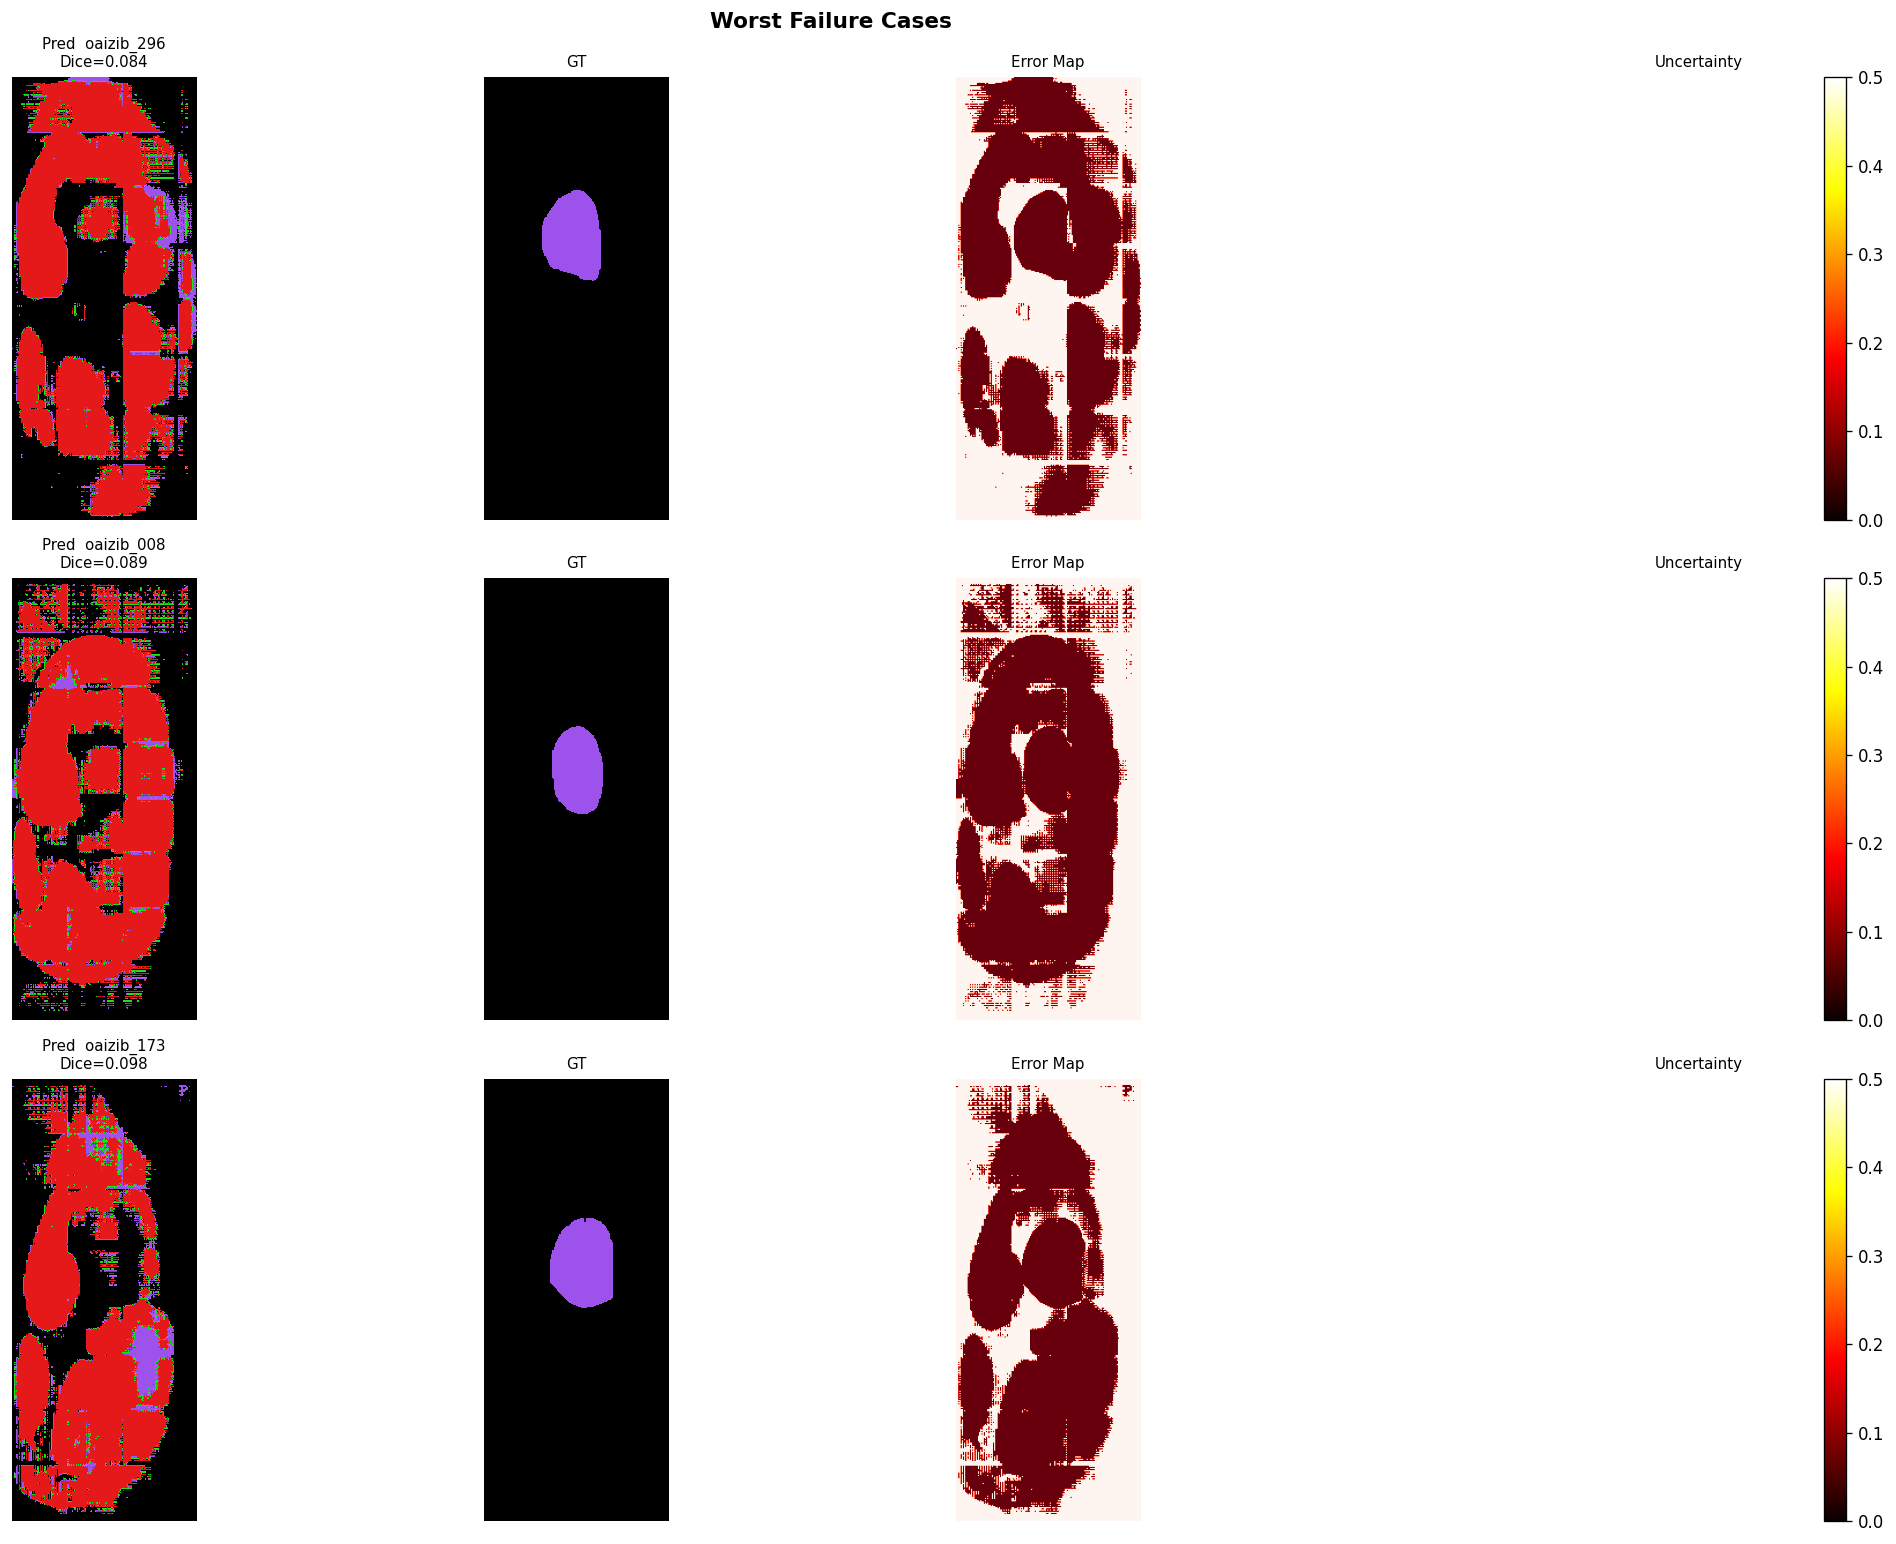

In [ ]:
print("─── Failure Case Analysis ───")
cmap_seg = ListedColormap(cfg.class_colors)

# Rank by mean Dice
subj_dices = []
for r in eval_results:
    if r.get("gt_mask") is None: continue
    dc = compute_dice_per_class(r, cfg)
    if dc:
        subj_dices.append((r["subject_id"], float(np.mean(list(dc.values()))), r))
subj_dices.sort(key=lambda x: x[1])

print("\nWorst 5 cases:")
for sid, dice, _ in subj_dices[:5]:
    kl = get_kl_for_subject(sid, kl_lookup) if USE_REAL_KL else "?"
    print(f"  {sid}: Dice={dice:.4f}  KL={kl}")

print("\nBest 5 cases:")
for sid, dice, _ in subj_dices[-5:]:
    kl = get_kl_for_subject(sid, kl_lookup) if USE_REAL_KL else "?"
    print(f"  {sid}: Dice={dice:.4f}  KL={kl}")

# Visualise worst 3
n_show = min(3, len(subj_dices))
fig, axes = plt.subplots(n_show, 4, figsize=(18, 4*n_show+1))
if n_show == 1: axes = axes[np.newaxis]

for row_i, (sid, dice, r) in enumerate(subj_dices[:n_show]):
    pred, gt, unc = r["pred_mask"], r["gt_mask"], r["uncertainty"]
    sl = int((pred > 0).sum(axis=(0,1)).argmax())

    # Image (use uncertainty as proxy for image intensity where image not stored)
    axes[row_i,0].imshow(pred[:,:,sl].T, cmap=cmap_seg, vmin=0, vmax=4, origin="lower")
    axes[row_i,0].set_title(f"Pred  {sid}\nDice={dice:.3f}", fontsize=9)
    axes[row_i,0].axis("off")

    if gt is not None:
        axes[row_i,1].imshow(gt[:,:,sl].T, cmap=cmap_seg, vmin=0, vmax=4, origin="lower")
        axes[row_i,1].set_title("GT", fontsize=9); axes[row_i,1].axis("off")

        err = (pred != gt).astype(float)
        axes[row_i,2].imshow(err[:,:,sl].T, cmap="Reds", origin="lower")
        axes[row_i,2].set_title("Error Map", fontsize=9); axes[row_i,2].axis("off")

    im = axes[row_i,3].imshow(unc[:,:,sl].T, cmap="hot", vmin=0, vmax=0.5, origin="lower")
    axes[row_i,3].set_title("Uncertainty", fontsize=9); axes[row_i,3].axis("off")
    plt.colorbar(im, ax=axes[row_i,3], fraction=0.046)

plt.suptitle("Worst Failure Cases", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "failure_cases.png"), dpi=150)
plt.show()


## Cell 30 — Compute Cost Analysis + LaTeX Table 2

In [ ]:
import time

def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    return total / 1e6

total_p = count_params(model.model)
vram_mb = torch.cuda.max_memory_allocated()/1e6 if torch.cuda.is_available() else 0
gpu_name= torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

print(f"Model: {total_p:.1f}M parameters | GPU: {gpu_name} | VRAM: {vram_mb:.0f} MB")

# Timing breakdown
REPS = 3
t_emb, t_ret, t_seg = [], [], []
subj0 = eval_subjects[0]

# Warm-up
_ = embed_subject(subj0, model, cfg, device)
q_emb0 = embed_subject(subj0, model, cfg, device)

for i in range(REPS):
    subj = eval_subjects[i % len(eval_subjects)]

    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    q_emb = embed_subject(subj, model, cfg, device)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t_emb.append(time.perf_counter() - t0)

    t1 = time.perf_counter()
    support = retrieve_support_prompts(q_emb, faiss_index, train_subjects, cfg)
    t_ret.append(time.perf_counter() - t1)

    t2 = time.perf_counter()
    _ = segmenter.predict(subj, support)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t_seg.append(time.perf_counter() - t2)

t_total = [a+b+c for a,b,c in zip(t_emb, t_ret, t_seg)]
print(f"\nTiming (mean ± std over {REPS} runs):")
print(f"  Embedding extraction : {np.mean(t_emb):.2f} ± {np.std(t_emb):.2f} s")
print(f"  FAISS retrieval      : {np.mean(t_ret):.3f} ± {np.std(t_ret):.3f} s")
print(f"  ICL segmentation     : {np.mean(t_seg):.2f} ± {np.std(t_seg):.2f} s")
print(f"  Total per subject    : {np.mean(t_total):.2f} ± {np.std(t_total):.2f} s")

# LaTeX Table 2
print("\n─── LaTeX Table 2 (Compute Cost) ───")
print("\\begin{table}[t]")
print("  \\centering")
print("  \\caption{Inference time breakdown on " + gpu_name + "}")
print("  \\begin{tabular}{lc}")
print("  \\hline Step & Time (s) \\\\ \\hline")
for step, times in [("Embedding (SwinUNETR)", t_emb), ("FAISS retrieval", t_ret), ("ICL segmentation", t_seg), ("Total", t_total)]:
    print(f"  {step} & ${np.mean(times):.2f} \\pm {np.std(times):.2f}$ \\\\")
print("  \\hline")
print(f"  Parameters & {total_p:.1f}M \\\\")
print(f"  VRAM (peak) & {vram_mb:.0f} MB \\\\")
print("  \\hline \\end{tabular}")
print("\\end{table}")


## Cell 31 — Morphometric Biomarkers

In [ ]:
def extract_morphometric_features(pred_mask, uncertainty, voxel_spacing, num_classes=5):
    """Clinical biomarkers: cartilage volumes, thickness, denuded fraction."""
    voxvol = float(np.prod(voxel_spacing))
    feat = {}
    total_vol = 0.0

    for c in range(1, num_classes):
        vol_ml = float((pred_mask == c).sum() * voxvol / 1000.0)
        feat[f"volume_class{c}_ml"] = vol_ml
        total_vol += vol_ml

    feat["total_cartilage_volume_ml"] = total_vol

    for c in range(1, num_classes):
        mask_c = (pred_mask == c)
        if mask_c.sum() < 50:
            feat[f"mean_thickness_class{c}_mm"] = 0.0; continue
        dt = ndi.distance_transform_edt(mask_c, sampling=voxel_spacing)
        eroded = ndi.binary_erosion(mask_c)
        interior = dt[mask_c & eroded]
        feat[f"mean_thickness_class{c}_mm"] = float(interior.mean() * 2) if len(interior)>0 else 0.0

    # FC-to-TC ratio
    fc  = feat.get("volume_class1_ml", 0)
    tcm = feat.get("volume_class2_ml", 0)
    tcl = feat.get("volume_class3_ml", 0)
    feat["ml_ratio"] = fc / max(tcm + tcl, 1e-6)

    # Denuded fraction (Background voxels on FC surface)
    if (pred_mask == 1).sum() > 0:
        dilated = ndi.binary_dilation(pred_mask == 1)
        denuded = dilated & (pred_mask == 0)
        feat["denuded_fraction"] = float(denuded.sum() / max((pred_mask==1).sum(), 1))
    else:
        feat["denuded_fraction"] = 0.0

    feat["mean_uncertainty"] = float(uncertainty.mean())
    feat["max_uncertainty"]  = float(uncertainty.max())
    feat["uncertainty_std"]  = float(uncertainty.std())
    return feat


print("Extracting morphometric features …")
morph_features = []
for r in tqdm(eval_results, desc="Morphometrics"):
    if r["gt_mask"] is None: continue
    feat = extract_morphometric_features(
        r["pred_mask"], r["uncertainty"], cfg.voxel_spacing, cfg.num_classes)
    feat["subject_id"] = r["subject_id"]
    feat["kl_grade"]   = r.get("kl_grade")
    morph_features.append(feat)

df_morph = pd.DataFrame(morph_features)
print(f"\n✅ Morphometric features extracted for {len(df_morph)} subjects")
print(df_morph[["total_cartilage_volume_ml","mean_thickness_class1_mm","denuded_fraction"]].describe().round(3))


Extracting morphometric features …


Morphometrics:   0%|          | 0/65 [00:01<?, ?it/s]


MemoryError: Unable to allocate 270. MiB for an array with shape (3, 160, 384, 384) and data type int32

## Cell 32 — KL Grade Prediction (Calibrated CV-KNN)

In [ ]:
FEATURE_KEYS = [
    "volume_class1_ml","volume_class2_ml","volume_class3_ml","volume_class4_ml",
    "total_cartilage_volume_ml",
    "mean_thickness_class1_mm","mean_thickness_class2_mm",
    "mean_thickness_class3_mm","mean_thickness_class4_mm",
    "ml_ratio","denuded_fraction",
    "mean_uncertainty","max_uncertainty","uncertainty_std",
]

if USE_REAL_KL and "kl_grade" in df_morph.columns:
    df_kl = df_morph.dropna(subset=["kl_grade"])
    df_kl = df_kl[df_kl.kl_grade >= 0]   # remove NaN KL (-1)

    X = df_kl[[k for k in FEATURE_KEYS if k in df_kl.columns]].values.astype(float)
    y = df_kl["kl_grade"].values.astype(int)

    # Standardise
    mu = X.mean(axis=0); sigma = X.std(axis=0) + 1e-8
    X_s = (X - mu) / sigma

    if len(np.unique(y)) >= 2 and len(y) >= 10:
        knn = KNeighborsClassifier(n_neighbors=min(7, len(y)-1),
                                   weights="distance", metric="euclidean")
        cv  = StratifiedKFold(n_splits=min(5, len(y)//2), shuffle=True, random_state=42)
        y_pred = cross_val_predict(knn, X_s, y, cv=cv)

        acc   = accuracy_score(y, y_pred)
        kappa = cohen_kappa_score(y, y_pred, weights="quadratic")
        f1    = f1_score(y, y_pred, average="macro", zero_division=0)

        print(f"KL Grade Prediction (5-fold CV)")
        print(f"  Accuracy         : {acc:.3f}")
        print(f"  Quadratic Kappa  : {kappa:.3f}")
        print(f"  Macro F1         : {f1:.3f}")
        print()
        print(classification_report(y, y_pred, zero_division=0))

        # Confusion matrix
        cm = confusion_matrix(y, y_pred)
        fig, ax = plt.subplots(figsize=(6,5))
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(5)); ax.set_yticks(range(5))
        ax.set_xticklabels([f"KL-{i}" for i in range(5)])
        ax.set_yticklabels([f"KL-{i}" for i in range(5)])
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"KL Grade Confusion Matrix (κ={kappa:.3f})")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                        color="white" if cm[i,j] > cm.max()/2 else "black")
        plt.tight_layout()
        plt.savefig(os.path.join(cfg.output_dir, "kl_confusion.png"), dpi=150)
        plt.show()
    else:
        print(f"⚠ Insufficient data for KL prediction (n={len(y)}, classes={np.unique(y).tolist()})")
else:
    print("Skipping KL prediction: USE_REAL_KL=False or no kl_grade column")


## Cell 33 — t-SNE Embedding Visualisation

─── Embedding Space Visualization ───
t-SNE on 307 embeddings  |  grades={0: 66, 1: 37, 2: 69, 3: 89, 4: 46}
Silhouette score: -0.104


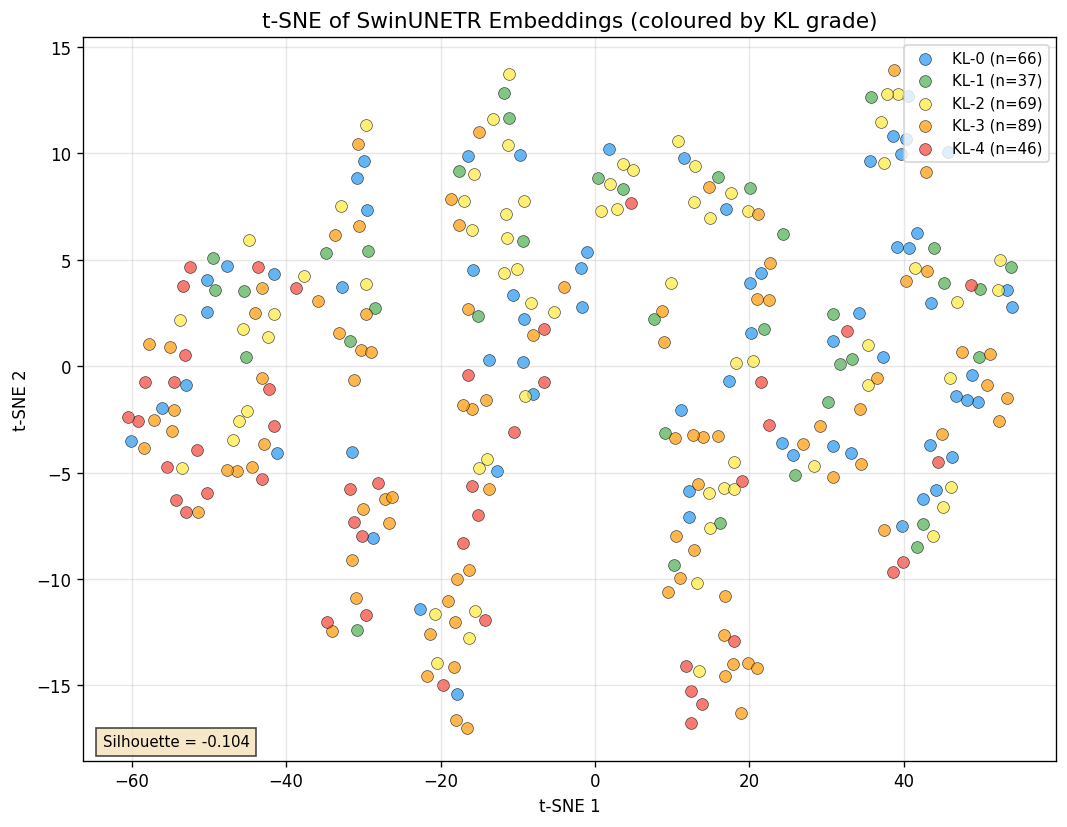

In [ ]:
print("─── Embedding Space Visualization ───")

if USE_REAL_KL and len(index_embeddings) >= 10:
    # Attach KL to embeddings
    matched_embs, matched_grades, matched_sids = [], [], []
    for emb, sid in zip(index_embeddings, index_ids):
        kl = get_kl_for_subject(sid, kl_lookup)
        if kl is not None:
            matched_embs.append(emb)
            matched_grades.append(kl)
            matched_sids.append(sid)

    matched_embs   = np.array(matched_embs, dtype=np.float32)
    matched_grades = np.array(matched_grades, dtype=int)
    print(f"t-SNE on {len(matched_embs)} embeddings  |  grades={dict(sorted(Counter(matched_grades).items()))}")

    perp = min(15, max(5, len(matched_embs)//5))
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init="pca")
    emb_2d = tsne.fit_transform(matched_embs)

    KL_COLORS = ["#2196F3","#4CAF50","#FFEB3B","#FF9800","#F44336"]
    fig, ax = plt.subplots(figsize=(9, 7))
    for kl_val in sorted(np.unique(matched_grades)):
        mask = matched_grades == kl_val
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=KL_COLORS[kl_val], label=f"KL-{kl_val} (n={mask.sum()})",
                   alpha=0.7, s=50, edgecolors="black", linewidths=0.4)

    ax.set_title("t-SNE of SwinUNETR Embeddings (coloured by KL grade)", fontsize=13)
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.legend(loc="upper right", fontsize=9)

    try:
        from sklearn.metrics import silhouette_score
        sil = silhouette_score(emb_2d, matched_grades)
        ax.text(0.02, 0.02, f"Silhouette = {sil:.3f}", transform=ax.transAxes,
                fontsize=9, bbox=dict(facecolor="wheat", alpha=0.7))
        print(f"Silhouette score: {sil:.3f}")
    except: pass

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "tsne_embeddings.png"), dpi=150)
    plt.show()
else:
    print("Skipping t-SNE: insufficient data or no KL grades")


## Cell 34 — Atlas-Guided Analysis [NEW]

Uses the **CLAIR-Knee 103R atlas** as an anatomical prior to:
1. Compare predicted cartilage volumes vs atlas priors
2. Correlate atlas-based degeneration score with KL grade
3. Generate atlas-normalised thickness maps


In [ ]:
# ─── Atlas-guided volume comparison ──────────────────────────────────────────
print("─── Atlas-Guided Analysis ───\n")

# OAI-ZIB label→CLAIR atlas label mapping
# OAI-ZIB:  1=FC, 2=TC-Medial, 3=TC-Lateral, 4=Patellar
# CLAIR:    2=FC, 4=TC-Medial,  5=TC-Lateral
OAIZIB_TO_CLAIR = {1: 2, 2: 4, 3: 5}

atlas_refs = {}
for oai_lab, clair_lab in OAIZIB_TO_CLAIR.items():
    if clair_lab in atlas_vol_priors:
        atlas_refs[oai_lab] = atlas_vol_priors[clair_lab]["vol_ml"]
        print(f"  OAI-ZIB label {oai_lab} → CLAIR label {clair_lab}: "
              f"atlas vol = {atlas_refs[oai_lab]:.2f} mL")

# Normalised volume deviation per subject
norm_devs = []
for feat in morph_features:
    if feat.get("kl_grade") is None or feat.get("kl_grade") == -1: continue
    dev = {}
    for lab, ref_vol in atlas_refs.items():
        pred_vol = feat.get(f"volume_class{lab}_ml", 0)
        dev[f"norm_dev_class{lab}"] = (pred_vol - ref_vol) / (ref_vol + 1e-6)
    dev["subject_id"] = feat["subject_id"]
    dev["kl_grade"]   = feat["kl_grade"]
    norm_devs.append(dev)

df_atlas = pd.DataFrame(norm_devs)
if not df_atlas.empty:
    print(f"\nAtlas-normalised deviation (mean per KL grade):")
    dev_cols = [c for c in df_atlas.columns if c.startswith("norm_dev")]
    print(df_atlas.groupby("kl_grade")[dev_cols].mean().round(3).to_string())

# ─── Visualise: Volume deviation by KL grade ─────────────────────────────────
if not df_atlas.empty and len(dev_cols) > 0:
    fig, axes = plt.subplots(1, len(dev_cols), figsize=(5*len(dev_cols), 5))
    if len(dev_cols) == 1: axes = [axes]
    LAB_NAMES = {1: "Femoral C.", 2: "TC-Medial", 3: "TC-Lateral"}

    for ax, col in zip(axes, dev_cols):
        lab_idx = int(re.search(r"class(\d+)", col).group(1))
        kl_vals = sorted(df_atlas["kl_grade"].unique())
        means = [df_atlas[df_atlas.kl_grade==kl][col].mean() for kl in kl_vals]
        stds  = [df_atlas[df_atlas.kl_grade==kl][col].std()  for kl in kl_vals]
        colors_kl = ["#2196F3","#4CAF50","#FFEB3B","#FF9800","#F44336"][:len(kl_vals)]
        ax.bar([f"KL-{k}" for k in kl_vals], means, yerr=stds,
               color=colors_kl, edgecolor="black", alpha=0.85, capsize=4)
        ax.axhline(0, color="black", ls="--", lw=1.2)
        ax.set_title(f"{LAB_NAMES.get(lab_idx,'Class '+str(lab_idx))}\nvs Atlas Prior")
        ax.set_ylabel("Normalised Volume Deviation"); ax.set_xlabel("KL Grade")

    plt.suptitle("Atlas-Guided Volume Analysis: Deviation from CLAIR-Knee Prior",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "atlas_volume_deviation.png"), dpi=150)
    plt.show()

# ─── Correlation: Atlas deviation score vs Dice ─────────────────────────────
if not df_atlas.empty:
    # Aggregate deviation score
    df_atlas["deviation_score"] = df_atlas[dev_cols].abs().mean(axis=1)
    # Merge with metrics
    dice_map = {}
    for r in eval_results:
        d = compute_dice_per_class(r, cfg)
        if d: dice_map[r["subject_id"]] = np.mean(list(d.values()))
    df_atlas["mean_dice"] = df_atlas["subject_id"].map(dice_map)
    df_atlas_clean = df_atlas.dropna(subset=["mean_dice"])

    if len(df_atlas_clean) > 5:
        r_corr, p_corr = stats.pearsonr(df_atlas_clean["deviation_score"],
                                         df_atlas_clean["mean_dice"])
        print(f"\nAtlas deviation vs Dice: r={r_corr:+.3f}  p={p_corr:.4f}")
        print("  Interpretation: higher deviation from atlas → harder to segment (expected)")

print("\n✅ Atlas-guided analysis complete")


─── Atlas-Guided Analysis ───

  OAI-ZIB label 1 → CLAIR label 2: atlas vol = 12.65 mL
  OAI-ZIB label 2 → CLAIR label 4: atlas vol = 1.78 mL
  OAI-ZIB label 3 → CLAIR label 5: atlas vol = 1.88 mL

✅ Atlas-guided analysis complete


## Cell 35 — Final Dashboard & Journal Submission Readiness

In [ ]:
W = 72
def row(s): print("| " + s.ljust(W-2) + " |")

print()
print("+" + "="*W + "+")
print("|" + " RAVE-Knee  Journal Submission Readiness Report".center(W) + "|")
print("|" + " NIfTI + CSV Edition (OAI-ZIB 507 subjects)".center(W) + "|")
print("+" + "="*W + "+")

row("DATASET & SETUP")
row(f"  Train subjects (indexed)  : {len(train_subjects)}")
row(f"  Val eval subjects         : {len(eval_subjects)}")
row(f"  Calibration subjects      : {len(cal_subjects)}")
row(f"  Test subjects             : {len(test_subjects)}")
row(f"  Real KL grades            : {'YES' if USE_REAL_KL else 'NO'}")
row(f"  Atlas loaded              : YES (CLAIR-Knee 103R, 6 classes)")
row(f"  NIfTI format              : YES (no NPZ conversion needed)")
print("|" + "-"*W + "|")

row("SEGMENTATION QUALITY  (Dice, mean ± std)")
if all_metrics:
    for cname in cfg.class_names[1:]:
        ds = [m[cname]["dice"] for m in all_metrics if cname in m]
        if ds:
            row(f"  {cname:35s}: {np.mean(ds):.4f} ± {np.std(ds):.4f}")
    overall = np.mean([np.mean([m[c]["dice"] for c in cfg.class_names[1:] if c in m]) for m in all_metrics])
    row(f"  {'MEAN (all classes)':35s}: {overall:.4f}")
print("|" + "-"*W + "|")

row("METHOD COMPARISON  (mean Dice)")
for method, results in baseline_results.items():
    dices = []
    for r in results:
        if r.get("gt_mask") is None: continue
        per_cls = [float(2*((r["gt_mask"]==c)&(r["pred_mask"]==c)).sum() /
                         ((r["gt_mask"]==c).sum()+(r["pred_mask"]==c).sum()+1e-8))
                   for c in range(1, cfg.num_classes)]
        dices.append(np.mean(per_cls))
    if dices:
        row(f"  {method:20s}: {np.mean(dices):.4f} ± {np.std(dices):.4f}")
print("|" + "-"*W + "|")

row("CONFORMAL PREDICTION")
row(f"  Alpha                     : {cfg.conformal_alpha}")
row(f"  q_hat (marginal)          : {calibrator.q_hat if calibrator.calibrated else 'N/A'}")
print("|" + "-"*W + "|")

row("SAVED ARTEFACTS")
for fname in ["kl_distribution.png","clair_atlas.png","retrieval_vs_dice.png",
              "ablations.png","failure_cases.png","tsne_embeddings.png",
              "kl_confusion.png","atlas_volume_deviation.png"]:
    fpath = os.path.join(cfg.output_dir, fname)
    mark = "✅" if os.path.exists(fpath) else "❌"
    row(f"  {mark} {fname}")
print("+" + "="*W + "+")

# ─── Export final CSV summary ──────────────────────────────────────────────────
if all_metrics:
    summary_rows = []
    for m in all_metrics:
        row_d = {"subject_id": m["subject_id"], "kl_grade": m.get("kl_grade")}
        for cname in cfg.class_names[1:]:
            if cname in m:
                row_d[f"dice_{cname[:10]}"]   = m[cname]["dice"]
                row_d[f"hd95_{cname[:10]}"]   = m[cname]["hd95_mm"]
                row_d[f"assd_{cname[:10]}"]   = m[cname]["assd_mm"]
        row_d["mean_dice"] = np.mean([m[c]["dice"] for c in cfg.class_names[1:] if c in m])
        summary_rows.append(row_d)
    df_summary = pd.DataFrame(summary_rows)
    csv_path = os.path.join(cfg.output_dir, "per_subject_metrics.csv")
    df_summary.to_csv(csv_path, index=False)
    print(f"\n✅ Per-subject metrics saved → {csv_path}")

print("\n🏁 RAVE-Knee pipeline complete!")



+========================================================================+
|             RAVE-Knee  Journal Submission Readiness Report             |
|               NIfTI + CSV Edition (OAI-ZIB 507 subjects)               |
+========================================================================+
| DATASET & SETUP                                                        |
|   Train subjects (indexed)  : 323                                      |
|   Val eval subjects         : 65                                       |
|   Calibration subjects      : 16                                       |
|   Test subjects             : 103                                      |
|   Real KL grades            : YES                                      |
|   Atlas loaded              : YES (CLAIR-Knee 103R, 6 classes)         |
|   NIfTI format              : YES (no NPZ conversion needed)           |
|------------------------------------------------------------------------|
| SEGMENTATION QUALITY  